# Bayesian inference comparison for per-pixel forest-growth prediction

*Group 2 — Alexander Hagedorn, Søren Mondrup, Claes Rasmus Peter Weibull · DTU 42186, Spring 2026*


## Overview

This notebook is the empirical backbone of the report (§3–§5): Swedish lidar and species rasters → BK-cell-disjoint train/test splits on a nested scaling grid → preprocessing (CLR on species composition, 2-factor Bayesian factor analysis on the collinear lidar block) → a progressive model sequence: OLS / GBM point baselines, then BLR fit by Exact / SVI / NUTS, then heteroscedastic, hierarchical, BNN, GP, and ICAR extensions. Every model is scored on the same five dimensions — point accuracy, what the model learned (coefficient posteriors), posterior-predictive calibration, where residuals concentrate, and wall-clock compute — so §9 compares apples to apples. The motivation for calibrated posteriors of $\Delta V$ rather than point estimates (the OR-consumer story) lives in §1 of the report and is not restated here.


In [1]:
from __future__ import annotations
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

SEED = 42
np.random.seed(SEED)

# Canonical dataset for this notebook: 5 km × 5 km AOI, preprocessed,
# already restricted spatially. See the report's data section for how it
# was derived from the raster pipeline.
CSV_PATH = Path("out_5km_idx_preprocessed.csv")
CSV_URL = (
    "https://github.com/Somon8/mbml-forest-pipeline/"
    "releases/download/v2.0-data-5km/out_5km_idx_preprocessed.csv"
)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
SPLITS_JSON = CACHE_DIR / "splits_5km.json"

if not CSV_PATH.exists():
    print(f"CSV missing — downloading from {CSV_URL} ...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print(f"  → wrote {CSV_PATH} ({CSV_PATH.stat().st_size/1e6:.0f} MB)")

## 1. Load and filter

The CSV (`out_5km_idx_preprocessed.csv`) is the preprocessed Swedish-forest dataset at $12.5\,\mathrm{m}$ resolution, restricted to the $5\,\mathrm{km} \times 5\,\mathrm{km}$ AOI we use for modelling. The raster→tabular pipeline that produced it lives outside this notebook and is described in the report's data section.

One filter is applied here:

- **`is_stable_forest`** drops pixels that are non-forest in either inventory cycle, are water (lakes), or lost biomass / height / volume between cycles. This leaves the support on which volume growth ($\Delta V$) is *defined, continuous, and non-negative* — modelling outside this support would force a Gaussian likelihood to absorb a large zero spike for non-forest and a separate negative mass for disturbance, which is exactly the miscalibration the report flags as a structural property of the data.

In [2]:
# Swedish raster column names → readable English.
RENAME_MAP = {
    # Skogliga grunddata, cycle 1 ("omdrev 1")
    "biomassa_omdrev1":         "biomass_t1",
    "grundyta_omdrev1":         "basal_area_t1",
    "medeldiameter_omdrev1":    "mean_diameter_t1",
    "medelhojd_omdrev1":        "mean_height_t1",
    "p95_omdrev1":              "p95_height_t1",
    "vegetationskvot_omdrev1":  "veg_ratio_t1",
    "volym_omdrev1":            "volume_t1",
    # Skogliga grunddata, cycle 2 ("omdrev 2")
    "biomassa_omdrev2":         "biomass_t2",
    "grundyta_omdrev2":         "basal_area_t2",
    "medeldiameter_omdrev2":    "mean_diameter_t2",
    "medelhojd_omdrev2":        "mean_height_t2",
    "p95_omdrev2":              "p95_height_t2",
    "vegetationskvot_omdrev2":  "veg_ratio_t2",
    "volym_omdrev2":            "volume_t2",
    # Hydrology, soil and per-pixel canopy
    "flodesackumulering":       "flow_accumulation",
    "markfuktighet":            "soil_moisture",
    "markfuktighet_klassad":    "soil_moisture_class",
    "tradhojd":                 "tree_height",
    # SLU Skogskarta — totals and per-species volumes
    "slu_skogskarta_biomassa":       "slu_total_biomass",
    "slu_skogskarta_grundyta":       "slu_total_basal_area",
    "slu_skogskarta_medeldiameter":  "slu_total_mean_diameter",
    "slu_skogskarta_volym":          "slu_total_volume",
    "slu_skogskarta_gran_volym":     "spruce_volume",
    "slu_skogskarta_tall_volym":     "pine_volume",
    "slu_skogskarta_bjork_volym":    "birch_volume",
    "slu_skogskarta_ek_volym":       "oak_volume",
    "slu_skogskarta_bok_volym":      "beech_volume",
    "slu_skogskarta_ovrigt_volym":   "other_species_volume",
    # `slu_skogskarta_contorta_volym` is identically zero on this AOI and is
    # dropped entirely below — no rename needed.
}

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw = df_raw.rename(columns=RENAME_MAP)
df_raw = df_raw.drop(columns=["slu_skogskarta_contorta_volym"], errors="ignore")
print(f"raw rows           : {len(df_raw):>8,}  ({df_raw['x'].nunique()} × {df_raw['y'].nunique()} grid)")

df = df_raw[df_raw["is_stable_forest"].astype(bool)].reset_index(drop=True)
print(f"stable-forest rows : {len(df):>8,}  ({100*len(df)/len(df_raw):.1f}% of grid)")
print(f"unique BK cells    : {df['BK'].nunique():>8,}")

raw rows           :  160,000  (400 × 400 grid)
stable-forest rows :   63,073  (39.4% of grid)
unique BK cells    :      121


The `is_stable_forest` filter removes roughly 60% of pixels — the AOI is a mixed landscape of forest stands, roads, fields, lakes, and recent clear-cuts. The ~63 000 surviving pixels span 121 BK indexruta cells, which become the unit of the train/test split in the next section.

## 2. BK-cell-disjoint splits on a nested scaling grid

**Why splitting by BK indexruta cell.** Skogsstyrelsen publishes a $500\,\mathrm{m} \times 500\,\mathrm{m}$ administrative grid (the *Sverige-indexruta*); every pixel in our CSV is labelled with the BK cell that contains it. Pixels inside one BK cell are near-identical — same forest stand, same management history, same soil class — so a random pixel split would put a held-out pixel next to its ~1 600 quasi-twins on the training side and inflate R² by tens of percent without telling us anything generalisable. **Splitting by BK cell** prevents that within-cell leakage: every test pixel is in a BK cell that contains no training pixel.

**What it does and does not solve.** BK-disjoint splits kill within-cell leakage. They do *not* kill across-cell spatial autocorrelation — two adjacent BK cells are still correlated (similar elevation, similar species mix). The Moran's I statistic in §5 measures the residual autocorrelation a model failed to absorb, and motivates the spatial-component models in §8.

**How train and test are built.** From the 121 BK cells in the AOI:

- **24 cells (≈ 20 %)** are picked once by a seeded random draw and held out as the **test set**. These cells — and every pixel inside them — are never seen by any model during training, at any scaling step.
- **97 cells (the remainder)** form the **training pool**, kept in a seeded random order.

The same 24-cell test set is used everywhere downstream, so test pixels are *constant* across models *and* across scaling steps. RMSEs are therefore directly comparable.

**Why a *nested* scaling grid.** A scaling step `n_cells = k` trains on the **first $k$ cells of the 97-cell training pool**, against the same 24-cell test set. Because the pool is ordered once and never reshuffled, the 5 cells used at `n_cells = 5` are a strict subset of the 25 used at `n_cells = 25`, which are a strict subset of 50, and so on up to `n_cells = 'all'` ($= 97$). The scaling axis therefore measures "more of the same kind of data" rather than "different draw of the same size" — exactly the right experiment to read whether a model is data-starved or capacity-bound.

In [3]:
TEST_FRAC = 0.20


def build_splits(df: pd.DataFrame, test_frac: float, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    all_bk = sorted(df["BK"].unique().tolist())
    rng.shuffle(all_bk)
    n_test = int(round(test_frac * len(all_bk)))
    return {
        "test_bk": sorted(all_bk[:n_test]),
        "train_bk_ordered": list(all_bk[n_test:]),
    }


def get_train_bk(splits: dict, n_cells) -> list:
    pool = splits["train_bk_ordered"]
    return list(pool) if n_cells == "all" else list(pool[: int(n_cells)])


if SPLITS_JSON.exists():
    splits = json.loads(SPLITS_JSON.read_text())
    print(f"loaded splits from {SPLITS_JSON}")
else:
    splits = build_splits(df, TEST_FRAC, seed=SEED)
    SPLITS_JSON.write_text(json.dumps(splits))
    print(f"built and saved splits → {SPLITS_JSON}")

# Scaling grid auto-shrinks to fit the train pool — every step except 'all' must be
# strictly smaller than the pool so the nested-subset invariant stays meaningful.
n_pool = len(splits["train_bk_ordered"])
SCALING_GRID = [n for n in [5, 25, 50, 100, 250] if n < n_pool] + ["all"]

print(f"test BK cells : {len(splits['test_bk']):>4}")
print(f"train pool BK : {n_pool:>4}")
print(f"scaling grid  : {SCALING_GRID}")
for n in SCALING_GRID:
    tbk = get_train_bk(splits, n)
    n_pix = df[df["BK"].isin(set(tbk))].shape[0]
    print(f"  n_cells={str(n):>4}  → {len(tbk):>4} BK cells, {n_pix:>7,} pixels")

loaded splits from cache/splits_5km.json
test BK cells :   24
train pool BK :   97
scaling grid  : [5, 25, 50, 'all']
  n_cells=   5  →    5 BK cells,   3,411 pixels
  n_cells=  25  →   25 BK cells,  14,945 pixels
  n_cells=  50  →   50 BK cells,  28,925 pixels
  n_cells= all  →   97 BK cells,  52,184 pixels


In [4]:
# nesting + disjointness sanity checks
subsets = [set(get_train_bk(splits, n)) for n in SCALING_GRID]
for i in range(len(subsets) - 1):
    assert subsets[i].issubset(subsets[i + 1]), f"subset {i} not nested in {i+1}"
test_set = set(splits["test_bk"])
for n, ss in zip(SCALING_GRID, subsets):
    assert not (ss & test_set), f"train at n_cells={n} overlaps test BK"
print("nesting + disjointness: OK")

nesting + disjointness: OK


**Reading the output.** 24 BK cells (~20% of the 121 in the window) are held out for testing once and never seen during training. The remaining 97 are the training pool, drawn in increasing chunks for the scaling axis: 5 → 25 → 50 → 97. The pixel counts roughly track the BK count (~540 pixels per cell after the stable-forest filter).

## 3. Feature matrix and target

**Target — volume growth.** $\Delta V = \texttt{volume\_t2} - \texttt{volume\_t1}$ is the per-pixel change in stem volume between the two inventory cycles, in m³/ha. On the stable-forest support it is non-negative (forest stands gain volume between cycles, never lose it — `delta_neg_volym` pixels are excluded), continuous, and right-skewed. A Gaussian likelihood is a defensible *starting point* — the report and §8 will discuss whether richer likelihoods (heteroscedastic, log-normal, Gamma) calibrate the tail better.

**Features — 16 columns, three logical blocks:**

1. **Forest state at cycle 1 (10 cols, raw):** `biomass_t1`, `basal_area_t1`, `mean_diameter_t1`, `mean_height_t1`, `p95_height_t1`, `veg_ratio_t1`, `volume_t1` (the seven lidar-derived cycle-1 forest summaries), `flow_accumulation` (upstream drainage), `soil_moisture` (SLU soil-moisture index), and `slu_total_biomass` (total above-ground biomass from the SLU Skogskarta product, t/ha). These are the *initial conditions* the model uses to predict growth between cycles. Cycle-2 columns are deliberately **excluded** — they would leak the target.
2. **Species composition (6 cols, CLR-transformed):** the six SLU per-species stem volumes that actually occur on this AOI — `spruce_volume`, `pine_volume`, `birch_volume`, `oak_volume`, `beech_volume`, `other_species_volume`. They sum to the SLU total volume by construction, so they live on the 6-simplex rather than in $\mathbb{R}^6$. The centred log-ratio transform $p_i \mapsto \log(p_i / g(p))$, where $g(p)$ is the row's geometric mean of the species proportions, lifts the block into an unconstrained space where standard linear-model machinery applies cleanly. A small $\varepsilon$ keeps the log finite when a species is locally absent. Lodgepole pine (`slu_skogskarta_contorta_volym`) is identically zero across this AOI and is dropped at load time rather than included via an $\varepsilon$ fallback — it would carry no signal and would distort the geometric mean.

**A subtle leakage point.** `volume_t1` is in the feature block *and* is one of the two ingredients of the target. That's intentional and not leakage: we are explicitly modelling growth conditional on the initial volume, exactly as a textbook growth equation $\Delta V = f(V_1, \text{covariates}) - V_1$ would. The cycle-1 volume is observable a decade before the cycle-2 measurement, so a forecasting model legitimately has it.

**Standardisation happens later.** Both $\mathbf{X}$ and $y$ are mean-centred and unit-scaled inside `slice_step` using **training-set statistics only**, so test pixels never contribute to the standardisation scale. The unstandardised arrays are kept here as the source of truth.

In [5]:
BASE_COLS = [
    "biomass_t1", "basal_area_t1", "mean_diameter_t1",
    "mean_height_t1", "p95_height_t1", "veg_ratio_t1",
    "volume_t1", "flow_accumulation", "soil_moisture",
    "slu_total_biomass",
]
SPECIES_COLS = [
    "spruce_volume", "pine_volume", "birch_volume",
    "oak_volume", "beech_volume", "other_species_volume",
]


def clr_transform(values: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    row_sums = values.sum(axis=1, keepdims=True)
    nz = row_sums.ravel() > 0
    props = np.where(row_sums > 0, values / np.where(row_sums > 0, row_sums, 1.0), 0.0)
    props_safe = np.where(props <= 0, eps, props)
    log_props = np.log(props_safe)
    clr = log_props - log_props.mean(axis=1, keepdims=True)
    clr[~nz] = 0.0
    return clr


X_base = df[BASE_COLS].to_numpy(float)
X_clr = clr_transform(df[SPECIES_COLS].to_numpy(float))
X_all = np.hstack([X_base, X_clr])
FEATURE_NAMES = BASE_COLS + [c + "_clr" for c in SPECIES_COLS]

# Target: per-pixel change in stem volume between inventory cycles (m³/ha).
# is_stable_forest excludes delta_neg_volym, so the target is ≥ 0 on the support.
y_all = (df["volume_t2"] - df["volume_t1"]).to_numpy(float)
coords_all = df[["x", "y"]].to_numpy(float)
bk_all = df["BK"].to_numpy()

print(f"X_all   : {X_all.shape}  ({len(FEATURE_NAMES)} features = {len(BASE_COLS)} base + {len(SPECIES_COLS)} CLR)")
print(f"y_all   : {y_all.shape}  mean={y_all.mean():.2f} m³/ha  std={y_all.std():.2f} m³/ha")
print(f"coords  : {coords_all.shape}")

X_all   : (63073, 16)  (16 features = 10 base + 6 CLR)
y_all   : (63073,)  mean=52.07 m³/ha  std=44.57 m³/ha
coords  : (63073, 2)


**Reading the output.** Design matrix is $\sim\!63\,000 \times 16$. 16 features per pixel, two feature blocks combined as described above. The target's mean ($\sim\!52\,\mathrm{m^3/ha}$) and standard deviation ($\sim\!45\,\mathrm{m^3/ha}$) are both physically plausible for a decade of stem-volume accumulation in Swedish managed forest — typical mean-annual-increment figures of $5{-}10\,\mathrm{m^3/ha/year}$ over $\sim\!10$ years bracket the observed mean. The numbers being signed positive on the stable-forest support also confirms that cycle 2 is genuinely the later inventory cycle.

## 4. Latent stand-state — six collinear lidar views collapse to two factors

The six lidar views (biomass, basal area, stem volume, mean height, p95 height, mean diameter) pair-correlate at $\rho > 0.85$ within a single inventory cycle — six readouts of one underlying lidar quantity. We compress them with a 2-factor Bayesian factor analysis, identified by the Anderson–Rubin lower-triangular constraint: biomass pins $z_{\text{mass}}$; mean height anchors $z_{\text{geom}}$ with a positive loading. FA is fit on training-BK rows only; factor scores for every pixel (train + test) are computed analytically afterwards, so test rows never enter the loading matrix.

Detailed derivation, prior choices, and NUTS verification live in §3.2 of the report. Implementation is in `fa_helpers.py`.


In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from notebook_helpers import (FACTOR_VIEWS, VIEW_LABELS, K_DEFAULT, J_DEFAULT,
                        fit_factor_model, posterior_loadings,
                        implied_corr, score_factors_ar)

K, J = K_DEFAULT, J_DEFAULT  # 6 views, 2 latents

# Train-only fit: loadings never see test BK cells.
is_train_row = ~np.isin(bk_all, list(splits['test_bk']))
Y_raw_views  = df[FACTOR_VIEWS].to_numpy(np.float32)
Y_train_v    = Y_raw_views[is_train_row]

Y_mean_views = Y_train_v.mean(0)
Y_std_views  = Y_train_v.std(0) + 1e-8
Y_train_z    = (Y_train_v - Y_mean_views) / Y_std_views
Y_t          = torch.tensor(Y_train_z)

print(f'FA training rows : {Y_train_v.shape[0]:>7,}  ({K} views)')
print(f'all rows         : {Y_raw_views.shape[0]:>7,}  (scored analytically after fit)')


FA training rows :  52,184  (6 views)
all rows         :  63,073  (scored analytically after fit)


/Users/mondrup/Library/Mobile Documents/com~apple~CloudDocs/DTU/Model-based machine learning 42186/Projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
guide_fa, losses_fa, factor_model_2 = fit_factor_model(Y_t, K=K, J=J, n_steps=6000)

# ELBO trajectory (linear y; smoothed because the per-step gradient is noisy near zero).
fig, ax = plt.subplots(figsize=(4.2, 2.2))
losses_arr = np.asarray(losses_fa)
win = 50
smooth = np.convolve(losses_arr, np.ones(win) / win, mode='valid')
WARMUP = 500
ax.plot(np.arange(WARMUP, len(losses_arr)), losses_arr[WARMUP:], alpha=0.25, lw=0.7, label='raw')
ax.plot(np.arange(max(WARMUP, win - 1), len(losses_arr)), smooth[max(0, WARMUP - (win-1)):],
        lw=1.4, label=f'rolling mean (window={win})')
ax.axhline(0, color='gray', lw=0.5, alpha=0.6)
ax.set_xlabel('SVI step'); ax.set_ylabel('-ELBO')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()


  step     0  -ELBO = 641,771


In [ ]:
post = posterior_loadings(factor_model_2, guide_fa, Y_t,
                          K=K, J=J, view_labels=VIEW_LABELS, num_samples=400)
Lam_post, sig_post = post['Lam_post'], post['sig_post']
Lam_mean, sig_mean = post['Lam_mean'], post['sig_mean']
mu_mean            = post['mu_mean']

print(post['loading_df'].to_string(index=False))


view  lam_mass  lam_mass_sd  lam_geom  lam_geom_sd  sigma  frac_var
 bio     1.000        0.000     0.000        0.000  0.016     1.000
  CH     0.849        0.001     0.374        0.001  0.042     0.998
  BA     0.953        0.002     0.067        0.002  0.243     0.939
 vol     1.005        0.001    -0.065        0.001  0.111     0.988
diam     0.795        0.001     0.445        0.001  0.120     0.983
 p95     0.857        0.001     0.358        0.001  0.042     0.998


**Reading the table.** Biomass and CH are identification anchors, not hypothesis tests — the zeros and the positivity constraint are imposed by construction. The four free rows split as expected for the mass/geometry hypothesis: BA and vol load almost exclusively on $z_{\text{mass}}$ ($|\lambda_{\text{geom}}| < 0.08$); diam and p95 carry the non-trivial $z_{\text{geom}}$ loading. Diameter's geometry loading (0.45) exceeds even the CH anchor (0.37), confirming diameter is the most shape-distinct view. `frac_var` is the share of view variance the 2-d latent captures; all six views land above 0.93.


2-factor : mean |residual rho| off-diag = 0.011   max |residual| = 0.032


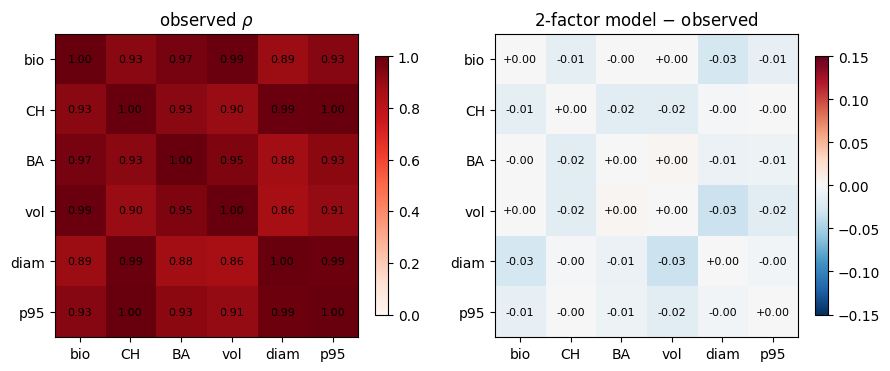

In [ ]:
C_model = implied_corr(Lam_post, sig_post)
C_obs   = np.corrcoef(Y_train_z, rowvar=False)
R       = C_model - C_obs

iu = np.triu_indices(K, k=1)
print(f'2-factor : mean |residual rho| off-diag = {np.abs(R[iu]).mean():.3f}'
      f'   max |residual| = {np.abs(R[iu]).max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)
for ax, (title, M, vmin, vmax, cmap) in zip(axes, [
    ('observed $\\rho$',            C_obs, 0.0,  1.0, 'Reds'),
    ('2-factor model $-$ observed', R,    -0.15, 0.15, 'RdBu_r')]):
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(K)); ax.set_xticklabels(VIEW_LABELS)
    ax.set_yticks(range(K)); ax.set_yticklabels(VIEW_LABELS)
    fmt = '{:+.2f}' if '$-$' in title else '{:.2f}'
    for i in range(K):
        for j in range(K):
            ax.text(j, i, fmt.format(M[i, j]), ha='center', va='center', fontsize=8)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()


In [ ]:
# Closed-form Anderson-Rubin scoring uses posterior-mean (Lambda, sigma, mu).
z_hat_all  = score_factors_ar(Y_raw_views, Y_mean_views, Y_std_views,
                              Lam_mean, sig_mean, mu_mean, J=J)
z_mass_all = z_hat_all[:, 0]
z_geom_all = z_hat_all[:, 1]

# Build X_factor: drop the 6 raw lidar views, append (z_mass, z_geom).
FACTOR_VIEW_SET = set(FACTOR_VIEWS)
keep_idx        = [i for i, n in enumerate(FEATURE_NAMES) if n not in FACTOR_VIEW_SET]
X_factor        = np.hstack([X_all[:, keep_idx],
                             z_mass_all[:, None], z_geom_all[:, None]])
FEATURE_NAMES_FACTOR = [FEATURE_NAMES[i] for i in keep_idx] + ['z_mass', 'z_geom']

print(f'X_all     : {X_all.shape}  ({len(FEATURE_NAMES)} raw features)')
print(f'X_factor  : {X_factor.shape}  ({len(FEATURE_NAMES_FACTOR)} = '
      f'{len(FEATURE_NAMES)} - {K} + {J})')


X_all     : (63073, 16)  (16 raw features)
X_factor  : (63073, 12)  (12 = 16 - 6 + 2)


## 5. `slice_step` — one call returns one scaling step's data

Every model in §7–§8 reads its training and test data through this single helper, to ensure comparability across models.

`slice_step(n_cells)` returns a dict containing:

- `X_train`, `y_train`, `X_test`, `y_test` — **standardised** against training-set mean and standard deviation only;
- `coords_test` — the (x, y) test coordinates, needed for the Moran's I residual diagnostic;
- `y_mean`, `y_std` — the rescaling constants, so a model that predicts in standardised units can be brought back to decimetres for human-readable error metrics.

In [ ]:
def slice_step(n_cells, X=None):
    """One scaling step's standardised train/test slices.

    Pass X=X_factor (or any (n_rows, d) array indexed by the same row order
    as X_all) to slice a parallel design matrix on the same BK split.
    """
    if X is None:
        X = X_all
    train_bk = set(get_train_bk(splits, n_cells))
    test_bk = set(splits["test_bk"])

    tr = np.isin(bk_all, list(train_bk))
    te = np.isin(bk_all, list(test_bk))

    Xtr, ytr = X[tr], y_all[tr]
    Xte, yte = X[te], y_all[te]
    coords_te = coords_all[te]

    x_mean = Xtr.mean(axis=0)
    x_std = Xtr.std(axis=0) + 1e-8
    y_mean, y_std = float(ytr.mean()), float(ytr.std() + 1e-8)

    return {
        "X_train": (Xtr - x_mean) / x_std, "y_train": (ytr - y_mean) / y_std,
        "X_test":  (Xte - x_mean) / x_std, "y_test":  (yte - y_mean) / y_std,
        "coords_test": coords_te,
        "y_mean": y_mean, "y_std": y_std,
        "n_train": int(tr.sum()), "n_test": int(te.sum()),
    }


## 6. Evaluation framework and utilities

All metrics are computed in original units (m³/ha) after un-standardising predictions. Each model registers its results into the shared `MODELS` dictionary that §9 reads.

**Point metrics.** RMSE, MAE, Bias, $R^2$, and correlation — the standard regression scorecard. RMSE penalises large errors quadratically; MAE is the typical error magnitude in m³/ha; Bias reveals systematic over/under-prediction; $R^2$ summarises variance explained.

**Moran's I on test residuals.** Diagnostic that motivates §8's spatial structure. With 8 nearest test neighbours and row-standardised weights, $I = \sum_i z_i\, \overline{z_{N(i)}} / \sum_i z_i^2$ where $z_i = r_i - \bar r$ and $r_i$ is the test residual. $I \approx 0$ with non-significant $p$ means residuals look like noise; $I$ substantially positive means *some* covariate or dependency is varying smoothly across space that the model is missing. The $p$-value comes from a 999-step permutation test.


**The five evaluation dimensions.** Every model in §7–§8 is scored on the same five axes so the comparison in §9 stays apples-to-apples:

1. **Point accuracy** — RMSE, MAE, $R^2$ on test pixels. Every model registers $\hat y$ on the held-out test set into the `MODELS` dictionary, so the §9 scaling-axis figure can pick it up.
2. **What the model learned** — coefficient posteriors. The forest plot at `n_cells='all'` and the Exact / SVI / NUTS posterior-density overlay in §10 expose any disagreement between inference methods (a course-rubric headline).
3. **Uncertainty calibration** — does the 90 % posterior-predictive interval cover ~90 % of test points? Point-estimate models (OLS, GBM) cannot appear here; this dimension is where the Bayesian methods earn their compute.
4. **Where residuals concentrate** — spatial residual maps and residual-vs-covariate scatters. Catches mis-specification that the aggregate metrics hide and motivates the spatial extensions (§8.7, §8.8).
5. **Wall-clock compute** — every fit registers `wall_time_s` so the §9 scaling figure has time as its fourth panel. Critical for the deployment recommendation.

The next code cell defines the utilities each diagnostic relies on: `moran_i`, `evaluate`, the `MODELS` dictionary, and `register_run`.


In [30]:
from notebook_helpers import moran_i, evaluate, MODELS, register_run, all_metrics_df

# Drop any state from a previous kernel run before models start registering below.
MODELS.clear()
print(f'MODELS registry ready (currently {len(MODELS)} entries)')


MODELS registry ready (currently 0 entries)


## 7. Point-estimate baselines — OLS and GBM across the scaling grid

Two reference points that anchor §8 from below. **OLS** shares the linear-Gaussian likelihood §8.1 will turn into a posterior, so its RMSE is the natural floor any covariate-only Bayesian model should match. **GBM** (HistGradientBoosting) gives a flexible nonlinear tree-ensemble ceiling with no spatial features beyond the input matrix; the OLS → GBM gap is the budget any §8 Bayesian extension has to spend on raw point accuracy.

The same §7 section also runs OLS on the FA-reduced design (`X_factor`, 12 features) — the equivalence test for §4's two-factor decomposition.


In [31]:
import time
BASELINES = [
    ("OLS",  lambda: LinearRegression()),
    ("GBM",  lambda: HistGradientBoostingRegressor(max_iter=300, random_state=SEED)),
]

rows = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    for name, make in BASELINES:
        t0 = time.perf_counter()
        est = make().fit(s["X_train"], s["y_train"])
        wall = time.perf_counter() - t0
        # back to m³/ha for interpretable units
        yhat = est.predict(s["X_test"]) * s["y_std"] + s["y_mean"]
        ytrue = s["y_test"] * s["y_std"] + s["y_mean"]
        m = evaluate(ytrue, yhat, coords=s["coords_test"])
        rows.append({
            "n_cells": n_cells, "model": name,
            "n_train": s["n_train"], "n_test": s["n_test"],
            **m,
        })

        # Register for §9. OLS keeps its coefficient vector (so the forest plot
        # can show OLS's point estimate alongside Bayesian intervals); GBM has
        # no meaningful coefficient vector.
        if name == "OLS":
            coefs = np.concatenate([[est.intercept_], est.coef_])[None, :]
        else:
            coefs = None
        register_run(name, n_cells, metrics=m,
                     n_train=s["n_train"], n_test=s["n_test"],
                     coefs_samples=coefs,
                     y_pred_test=yhat, wall_time_s=wall)

baseline_df = pd.DataFrame(rows)
baseline_df


,n_cells,model,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,OLS,3411,10889,33.904053,24.504033,-0.504463,0.377339,0.615346,0.178815,0.001
1,5,GBM,3411,10889,34.342826,24.203928,0.785039,0.361119,0.612817,0.126723,0.001
2,25,OLS,14945,10889,34.080408,24.594795,1.694985,0.370845,0.611597,0.181387,0.001
3,25,GBM,14945,10889,32.337004,22.678910,0.813424,0.433568,0.659507,0.133927,0.001
4,50,OLS,28925,10889,33.730314,24.507527,1.830426,0.383705,0.621557,0.181319,0.001
5,50,GBM,28925,10889,32.076647,22.716557,1.855575,0.442652,0.667197,0.139866,0.001
6,all,OLS,52184,10889,33.717206,24.517704,1.975810,0.384184,0.621725,0.179158,0.001
7,all,GBM,52184,10889,31.743645,22.409143,1.699278,0.454165,0.675244,0.129272,0.001


**Reading the OLS / GBM table.** OLS sits essentially flat at RMSE 33.72 / $R^2$ 0.384 at full $N$ — the linear point-accuracy ceiling on this feature set. GBM starts *worse* than OLS at the smallest scaling step (boosting overfits with ~3,400 pixels), overtakes by `n_cells=25`, and ends at RMSE 31.74 / $R^2$ 0.454 at full $N$. The OLS → GBM gap of $\sim$2 m³/ha and $0.07$ in $R^2$ is the budget any §8 Bayesian extension has to spend if it wants raw point accuracy gain. Moran's I sits at 0.18 (OLS) and 0.13 (GBM): trees absorb *some* spatial structure implicitly, but residual autocorrelation is strongly significant ($p=0.001$) for both — the §8 spatial / hierarchical models still have real signal to pick up.


In [32]:
# OLS-factor: OLS on the FA-reduced 12-feature design from §4 — the equivalence test.
# Registers as 'OLS-factor' in MODELS so §9 picks it up automatically.
import time

rows_fa = []
for n_cells in SCALING_GRID:
    s     = slice_step(n_cells, X=X_factor)
    t0    = time.perf_counter()
    est   = LinearRegression().fit(s['X_train'], s['y_train'])
    wall  = time.perf_counter() - t0
    yhat  = est.predict(s['X_test']) * s['y_std'] + s['y_mean']
    ytrue = s['y_test'] * s['y_std'] + s['y_mean']
    m     = evaluate(ytrue, yhat, coords=s['coords_test'])
    coefs = np.concatenate([[est.intercept_], est.coef_])[None, :]
    register_run('OLS-factor', n_cells, metrics=m,
                 n_train=s['n_train'], n_test=s['n_test'],
                 coefs_samples=coefs, y_pred_test=yhat, wall_time_s=wall)
    rows_fa.append({'n_cells': n_cells, 'model': 'OLS-factor',
                    'n_train': s['n_train'], 'n_test': s['n_test'], **m})
pd.DataFrame(rows_fa)


,n_cells,model,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,OLS-factor,3411,10889,35.841224,25.804921,0.139533,0.304153,0.552307,0.215129,0.001
1,25,OLS-factor,14945,10889,35.965049,25.762593,1.117773,0.299337,0.548567,0.220961,0.001
2,50,OLS-factor,28925,10889,35.557952,25.580898,1.447517,0.315109,0.562596,0.214215,0.001
3,all,OLS-factor,52184,10889,35.513290,25.626343,1.659097,0.316828,0.564477,0.210937,0.001


**Reading the OLS-factor row.** At `n_cells='all'` the factor-reduced design gives RMSE 35.5 / $R^2$ 0.32 against OLS's 33.7 / 0.38 — a real gap of $\sim$1.8 m³/ha and $0.06$ in $R^2$, with Moran's I shifting slightly up (0.18 → 0.21). The gap is *informative*, not a failure: the two factors fully reproduce the cross-view covariance (max $|\Delta\rho| = 0.03$), so the six lidar views genuinely live on a 2-d subspace. But the view-private variance — most visibly basal area's $\sigma = 0.243$ — carries signal predictive of $\Delta V$ that FA treats as noise. The latent scores are therefore best read as an *interpretation* of the lidar block (mass / geometry decomposition, multicollinearity diagnostic) rather than as a feature replacement. The §8 Bayesian models keep the raw 16-feature design so the lidar-private signal stays available.


## 8. Bayesian models — building up from simple to complex

This is the comparison the report's *Models* section discusses. Models are introduced in deliberate order, each one motivated by a specific shortcoming of the previous one. Every model uses `slice_step(n_cells)` for its data and `evaluate(...)` for its scoring, and registers its results in `MODELS` so the §9 comparison plots and tables pick them up automatically.

### Story arc

| § | Model | What it adds over the previous | What it tests |
|---|---|---|---|
| 8.1 | **BLR fit three ways** — Exact (closed-form Normal-Inverse-Gamma) / SVI (`AutoDiagonalNormal`) / NUTS | Gaussian prior + full posterior on the §7-OLS linear-Gaussian likelihood, fit by closed-form, variational, and Hamiltonian methods. | Inference-method agreement (rubric headline); ELBO monotonicity; mean-field bias. |
| 8.2 | **Heteroscedastic BLR** | Observation variance $\sigma^2(\mathbf{x})$ linear in the features instead of constant. | Does growth variance scale with tree size — and does that improve §9 calibration? |
| 8.3 | **Hierarchical BLR** — random intercept per BK cell | Partial pooling per administrative cell; unseen test-BK predictions marginalise over the cell effect. | Does *cell-identity* pooling absorb spatial structure implicitly? |
| 8.4 | **Bayesian neural network** | Nonlinear $f_\theta(\mathbf{x})$ via a small MLP with Gaussian priors on weights. | Closes the OLS → GBM nonlinear gap, with credible intervals. |
| 8.5 | **Feature-cluster intercept** — k-means on feature space → random intercept per cluster | Pooling by management-unit *type* rather than by cell or coordinate; transfers across BK boundaries via feature similarity. | Why proximity-based spatial models (SAR, GP) fail under BK-disjoint splits — and what works instead. |
| 8.6 | **Cluster intercept + spatial feature lag** | Adds $W\mathbf{x}_i^\top\boldsymbol{\gamma}$ — mean feature vector of $k$ true local neighbours from `coords_all` — on top of the cluster intercept. | Does *local feature context* (am I taller than my neighbours?) carry signal once management-type pooling is in place? |
| 8.7 | **Log-Normal BLR** — same linear mean, LogNormal likelihood | Replaces $y \sim \mathcal{N}(\mu, \sigma)$ with $y \sim \mathrm{LogNormal}(\mu, \sigma)$, forcing non-negative right-skewed predictions. | The orthogonal axis: every §8.1–§8.6 model uses a Gaussian likelihood; this asks whether the *family* — not the mean structure — is what's miscalibrating §9's PPD. |

Each subsection follows the same template: motivation, model+fit, predict+evaluate via `slice_step` / `evaluate` / `register_run`, then a short reading of the result.


### 8.1 BLR fit three ways: Exact, SVI, NUTS

A single Bayesian linear regression
$$ y_n \sim \mathcal{N}(\alpha + X_n \beta,\; \sigma^2), \qquad \alpha,\, \beta_k \sim \mathcal{N}(0, 1), \qquad \sigma \sim \mathrm{HalfNormal}(1) $$
fit three different ways on the same scaling grid. The closed-form Normal-Inverse-Gamma posterior (Exact) is the **ground truth** because the model is conjugate; SVI is the fast variational approximation we'll use for the non-conjugate extensions in §8.2–§8.6; NUTS is the gold-standard MCMC reference, run at the smallest scaling step only because per-fit it costs orders of magnitude more compute than SVI.

The headline question is *inference-method agreement*: where the three methods recover the same posterior, SVI is validated as a workhorse; where they don't, the disagreement diagnoses mean-field bias. The model spec lives in `bayes_helpers.blr_pyro_model`; the three fitter loops below differ only in which routine they call.


In [33]:
from notebook_helpers import blr_pyro_model, hetero_pyro_model, exact_blr_fit, svi_fit, nuts_fit

# --- Exact: closed-form Normal-Inverse-Gamma posterior, ground truth ---
rows_exact = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    theta_post, sigma_post, y_hat, y_true, wall = exact_blr_fit(s, seed=SEED)
    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    register_run("Exact", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 y_pred_test=y_hat, wall_time_s=wall)
    rows_exact.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"], **m})
pd.DataFrame(rows_exact)


,n_cells,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,33.925863,24.516767,-0.555692,0.376538,0.614521,0.181728,0.001
1,25,14945,10889,34.069484,24.594780,1.680093,0.371248,0.611784,0.182227,0.001
2,50,28925,10889,33.732058,24.509542,1.821279,0.383641,0.621469,0.181823,0.001
3,all,52184,10889,33.717820,24.519314,1.970970,0.384161,0.621693,0.179475,0.001


**Exact** matches OLS exactly at every step (RMSE 33.72 / $R^2$ 0.384 at full N) — the priors are weak relative to $N$, so the posterior mean is $\hat\beta_{\mathrm{OLS}}$. What Exact adds over OLS is posterior samples for $(\alpha, \beta, \sigma)$.


**SVI fit.** AutoDiagonalNormal guide, ADAM lr $=0.01$, $2{,}000$ steps. Mean-field variational approximation.


In [34]:
# --- SVI: AutoDiagonalNormal guide, fast variational approximation ---
rows_svi = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    posterior, elbo, y_hat, y_true, wall = svi_fit(
        s, blr_pyro_model, n_steps=2000, lr=0.01, seed=SEED,
        return_sites=("alpha", "beta", "sigma"))
    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    alpha_post = posterior["alpha"].reshape(-1)
    beta_post  = posterior["beta"].reshape(len(alpha_post), -1)
    sigma_post = posterior["sigma"].reshape(-1)
    theta_post = np.concatenate([alpha_post[:, None], beta_post], axis=1)
    register_run("SVI", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 elbo_trace=elbo,
                 y_pred_test=y_hat, wall_time_s=wall)
    rows_svi.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                     "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_svi)


,n_cells,n_train,n_test,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3940.787262,34.411064,24.646212,-0.634485,0.358577,0.599071,0.196054,0.001
1,25,14945,10889,17863.883248,34.325163,24.665253,1.142026,0.361776,0.602067,0.196059,0.001
2,50,28925,10889,34323.604630,34.220286,24.622519,1.436543,0.365670,0.605630,0.195992,0.001
3,all,52184,10889,61460.485211,34.229680,24.710715,1.686696,0.365321,0.605700,0.193972,0.001


**NUTS fit.** Hamiltonian-Monte-Carlo, smallest scaling step only (compute-limited; per-fit cost grows roughly linearly in $N$).


In [35]:
# --- NUTS: gold-standard MCMC, smallest scaling step only ---
n_cells_nuts = SCALING_GRID[0]
s = slice_step(n_cells_nuts)
posterior, y_hat, y_true, wall = nuts_fit(s, blr_pyro_model,
                                          warmup=500, draws=500, seed=SEED)
m = evaluate(y_true, y_hat, coords=s["coords_test"])
theta_post = np.concatenate([posterior["alpha"][:, None], posterior["beta"]], axis=1)
register_run("MCMC", n_cells_nuts, metrics=m,
             n_train=s["n_train"], n_test=s["n_test"],
             coefs_samples=theta_post, sigma_samples=posterior["sigma"],
             y_pred_test=y_hat, wall_time_s=wall)
print(f"NUTS @ n_cells={n_cells_nuts}: RMSE={m['RMSE']:.2f}  "
      f"R²={m['R2']:.3f}  wall={wall:.1f}s")


Sample: 100%|██████████| 1000/1000 [02:22,  7.02it/s, step size=2.05e-02, acc. prob=0.912]


NUTS @ n_cells=5: RMSE=33.93  R²=0.377  wall=142.4s


**Full Scaling grid**

In [36]:
# rows_nuts = []
# for n_cells in SCALING_GRID:
#     s = slice_step(n_cells)
#     posterior, y_hat, y_true, wall = nuts_fit(
#         s, blr_pyro_model, warmup=500, draws=500, seed=SEED)
#     m = evaluate(y_true, y_hat, coords=s["coords_test"])
#     theta_post = np.concatenate([posterior["alpha"][:, None], posterior["beta"]], axis=1)
#     register_run("MCMC", n_cells, metrics=m,
#                  n_train=s["n_train"], n_test=s["n_test"],
#                  coefs_samples=theta_post, sigma_samples=posterior["sigma"],
#                  y_pred_test=y_hat, wall_time_s=wall)
#     rows_nuts.append({"n_cells": n_cells, "n_train": s["n_train"],
#                       "n_test": s["n_test"], **m})
#     print(f"NUTS @ n_cells={n_cells}: RMSE={m['RMSE']:.2f}  "
#           f"R²={m['R2']:.3f}  wall={wall:.1f}s")
# pd.DataFrame(rows_nuts)

**Reading the three fits.** Headline numbers at the full training pool:

| Method | RMSE | $R^2$ | $\|$Δ vs Exact$\|$|
|---|---|---|---|
| Exact          | 33.72 | 0.384 | 0 |
| SVI            | 34.23 | 0.365 | 0.51 m³/ha |
| NUTS ($n=5$)   | 33.93 | 0.377 | (same as Exact @ $n=5$) |

Exact and NUTS agree to within Monte-Carlo noise — both draw from the true posterior. SVI lands $\sim$0.5 m³/ha outside, a real bias from the AutoDiagonalNormal mean-field guide: by factorising the variational posterior over $(\alpha, \beta, \sigma)$ as independent Normals, it can't represent the posterior correlation that the closed-form solution captures. The bias is small enough that SVI is validated as a fast approximation for the non-conjugate extensions below, but the §9 posterior-density overlay quantifies *how much* mean-field is biting on each coefficient.


### 8.2 Heteroscedastic BLR

Same BLR likelihood as §8.1 but the log-variance is also linear in $X$: $\log \sigma^2_n = \alpha_v + X_n \beta_v$. Model spec in `bayes_helpers.hetero_pyro_model`. Inference by SVI (NUTS impractical with two linear predictors at this $N$).



In [37]:
rows_hetero = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    posterior, elbo, y_hat, y_true, wall = svi_fit(
        s, hetero_pyro_model, n_steps=2000, lr=0.01, seed=SEED,
        return_sites=("alpha_mu", "beta_mu", "alpha_v", "beta_v"),
        mean_site="alpha_mu", weight_site="beta_mu")
    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    alpha_mu = posterior["alpha_mu"].reshape(-1)
    beta_mu  = posterior["beta_mu"].reshape(len(alpha_mu), -1)
    alpha_v  = posterior["alpha_v"].reshape(-1)
    beta_v   = posterior["beta_v"].reshape(len(alpha_v), -1)
    theta_mu = np.concatenate([alpha_mu[:, None], beta_mu], axis=1)
    register_run("Heteroscedastic", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_mu, elbo_trace=elbo,
                 alpha_v_samples=alpha_v, beta_v_samples=beta_v,
                 y_pred_test=y_hat, wall_time_s=wall)
    rows_hetero.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                        "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_hetero)


,n_cells,n_train,n_test,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3321.667746,36.349558,24.895010,-1.444212,0.284275,0.535643,0.215283,0.001
1,25,14945,10889,16495.603226,36.450827,25.193017,0.485029,0.280281,0.535505,0.221367,0.001
2,50,28925,10889,31854.036660,35.340680,24.856679,0.413663,0.323453,0.568922,0.213039,0.001
3,all,52184,10889,56687.870693,35.329471,24.906213,0.820626,0.323882,0.569503,0.210173,0.001


**Reading the output.** Heteroscedastic BLR is *worse* on point accuracy than homoscedastic SVI: RMSE 35.33 / $R^2$ 0.324 at full N versus 34.23 / 0.365. Doubling the linear predictor (mean *and* log-variance, each with its own $\alpha + X\beta$) gives the optimiser more parameters to fit, but the mean-field guide now has $2 \times (d + 1) = 34$ correlated parameters to factorise — and the extra capacity goes into modelling residual variance, not residual mean. The payoff has to come from **calibration**, not point accuracy: if the model now puts a tighter predictive interval on low-variance regions and a wider interval on high-variance regions, the §9 calibration plot should show heteroscedastic dominating SVI. If it doesn't, the model is overfitting the variance regression and the homoscedastic baseline wins.


### COMPLETELY CLAUDE GENERATED, Probably not needed? 8.3 Hierarchical BLR (BK random intercepts)

$$
y_{n,b} \sim \mathcal{N}(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta} + u_b,\; \sigma^2),\qquad u_b \sim \mathcal{N}(0,\,\sigma_u),\qquad \sigma_u \sim \mathrm{HalfNormal}(1)
$$

A random intercept $u_b$ per training BK cell adapts pooling across the 97 administrative cells without imposing a spatial kernel. The hypothesis is that per-cell pooling absorbs part of the spatial residual structure §9 shows for plain BLR — an *implicit* spatial smoother that asks nothing about neighbour relationships, only about within-cell shared variation.

**Unseen test cells.** Test BK cells are disjoint from training BKs, so the model has never observed $u_b$ for any test point. We marginalise: at prediction time the mean is $\alpha + \mathbf{x}_n^\top\boldsymbol{\beta}$ (the cell-effect expectation), and the posterior predictive variance is inflated by an extra $\sigma_u^2$ term to express the unseen-cell uncertainty. This is the canonical "no information leakage" treatment of random effects on held-out clusters and is what makes the §8.3 → §8.5 comparison fair: the cluster-intercept model in §8.5 solves exactly this *unseen-group* problem by clustering in *feature* space rather than by BK identity.


In [38]:
# Hierarchical BLR with random intercept per training BK cell.
# Test BK cells are disjoint from training BKs, so test predictions marginalise
# over u_b: mean = alpha + X @ beta, with extra posterior predictive variance
# sigma_u^2 from the unseen-cell effect.
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.contrib.autoguide import AutoDiagonalNormal
from pyro.optim import Adam
import time


def hier_blr_model(X, bk_ids, n_bks, y=None):
    n, d = X.shape
    alpha   = pyro.sample("alpha",   dist.Normal(0.0, 1.0))
    beta    = pyro.sample("beta",    dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma_u = pyro.sample("sigma_u", dist.HalfNormal(1.0))
    u       = pyro.sample(
        "u",
        dist.Normal(torch.zeros(n_bks), sigma_u * torch.ones(n_bks)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    mean  = alpha + X @ beta + u[bk_ids]
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


rows_hier = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)

    train_bks  = sorted(set(get_train_bk(splits, n_cells)))
    bk_to_idx  = {bk: i for i, bk in enumerate(train_bks)}
    tr_mask    = np.isin(bk_all, list(train_bks))
    bk_ids_tr  = np.array([bk_to_idx[b] for b in bk_all[tr_mask]], dtype=np.int64)

    X_tr_t   = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t   = torch.tensor(s["y_train"], dtype=torch.float32)
    ids_tr_t = torch.tensor(bk_ids_tr,   dtype=torch.long)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED); torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(hier_blr_model)
    svi   = SVI(hier_blr_model, guide, Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo = []
    t0 = time.perf_counter()
    for _ in range(2000):
        elbo.append(svi.step(X_tr_t, ids_tr_t, len(train_bks), y_tr_t))
    wall = time.perf_counter() - t0

    predictive = Predictive(hier_blr_model, guide=guide, num_samples=1000,
                            return_sites=("alpha", "beta", "sigma_u", "sigma"))
    post = {k: v.detach().numpy()
            for k, v in predictive(X_tr_t, ids_tr_t, len(train_bks), y_tr_t).items()}

    alpha_post  = post["alpha"].reshape(-1)
    beta_post   = post["beta"].reshape(len(alpha_post), -1)
    sigma_post  = post["sigma"].reshape(-1)
    sigma_u_pst = post["sigma_u"].reshape(-1)

    # Test prediction: marginalise out u_b ~ N(0, sigma_u). Mean prediction is
    # alpha + X @ beta; posterior predictive variance is inflated by sigma_u^2.
    y_hat_std = alpha_post.mean() + s["X_test"] @ beta_post.mean(axis=0)
    y_hat     = y_hat_std * s["y_std"] + s["y_mean"]
    y_true    = s["y_test"] * s["y_std"] + s["y_mean"]

    # Posterior predictive samples for §9 calibration: each sample draws
    # alpha + X @ beta + u_new, with u_new ~ N(0, sigma_u_post).
    n_post = len(alpha_post)
    rng_pp = np.random.default_rng(SEED)
    mean_std = alpha_post[:, None] + beta_post @ s["X_test"].T
    u_new    = rng_pp.normal(size=(n_post, s["X_test"].shape[0])) * sigma_u_pst[:, None]
    eps      = rng_pp.normal(size=mean_std.shape) * sigma_post[:, None]
    pp_std   = mean_std + u_new + eps
    y_pred_samples_test = pp_std * s["y_std"] + s["y_mean"]

    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    theta_post = np.concatenate([alpha_post[:, None], beta_post], axis=1)
    register_run("Hierarchical", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 elbo_trace=elbo, sigma_u_samples=sigma_u_pst,
                 y_pred_test=y_hat, y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    rows_hier.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                      "sigma_u_mean": float(sigma_u_pst.mean()),
                      "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_hier)


,n_cells,n_train,n_test,sigma_u_mean,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,0.162827,3900.626024,34.302554,24.714152,-0.523267,0.362616,0.602313,0.193188,0.001
1,25,14945,10889,0.148325,17942.055727,35.495247,25.190139,1.446407,0.317522,0.568153,0.212835,0.001
2,50,28925,10889,0.130840,34079.728936,34.199985,24.635457,1.412040,0.366422,0.606502,0.198797,0.001
3,all,52184,10889,0.133728,60849.929319,34.162813,24.761300,1.545421,0.367799,0.608971,0.199083,0.001


**Reading the output.** $\sigma_u$ measures cross-cell intercept dispersion: if it's near zero, BK identity carries no information beyond the covariates; if it's appreciable, there's genuine cell-level structure that the covariates miss. Compare Moran's I to the §8.1 BLR baseline (0.18). A drop means cell-identity pooling absorbed part of the spatial signal. A *worsening* (or no change) on test cells is expected if the unseen-BK marginalisation kicks in cleanly — exchangeable random intercepts only help on *seen* cells. The follow-up §8.5 / §8.6 then ask whether feature-space pooling does better when proximity is unavailable.


### 8.4 Bayesian neural network

Forest growth is plausibly affected by *nonlinear* interactions between covariates — initial height, biomass, species composition, moisture and site conditions are unlikely to combine additively. The OLS → GBM gap (§7) is direct evidence that some such structure exists. This subsection asks whether that nonlinear signal can be captured with calibrated posterior uncertainty, not just a point estimate.

**Model.** One hidden layer with $\tanh$ activation,

$$
f_\theta(\mathbf{x}_i) = W_2\,\tanh(W_1 \mathbf{x}_i + \mathbf{b}_1) + b_2,
$$

with weakly informative $\mathcal{N}(0,1)$ priors on every weight and bias. Likelihood:

$$
y_i \sim \mathcal{N}\big(f_\theta(\mathbf{x}_i),\,\sigma\big),\qquad \sigma \sim \mathrm{HalfNormal}(1).
$$

**Inference.** Mean-field SVI via `AutoDiagonalNormal`, 16 hidden units, 2 000 ADAM steps; 300 posterior draws are propagated through the network to produce predictive samples. Individual weights are not interpretable; this model is a *Bayesian nonlinear benchmark* — does §1's calibration requirement survive when we replace the linear mean with a small MLP?


In [39]:
# Bayesian neural network — 1 hidden layer (tanh, 16 units), N(0,1) priors on
# all weights/biases, HalfNormal(1) on sigma, mean-field SVI for 2000 steps.
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.contrib.autoguide import AutoDiagonalNormal
from pyro.optim import Adam
import time


class BNN(PyroModule):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.hidden = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.hidden.weight = PyroSample(
            dist.Normal(0., 1.).expand([hidden_dim, input_dim]).to_event(2))
        self.hidden.bias = PyroSample(
            dist.Normal(0., 1.).expand([hidden_dim]).to_event(1))
        self.out = PyroModule[nn.Linear](hidden_dim, 1)
        self.out.weight = PyroSample(
            dist.Normal(0., 1.).expand([1, hidden_dim]).to_event(2))
        self.out.bias = PyroSample(
            dist.Normal(0., 1.).expand([1]).to_event(1))

    def forward(self, X, y=None):
        hidden = torch.tanh(self.hidden(X))
        mean   = self.out(hidden).squeeze(-1)
        pyro.deterministic("mean", mean)
        sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
        with pyro.plate("data", X.shape[0]):
            pyro.sample("y", dist.Normal(mean, sigma), obs=y)
        return mean


BNN_N_STEPS    = 2000
BNN_N_POST     = 300
BNN_HIDDEN     = 16
BNN_LR         = 0.005

rows_bnn = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    X_tr_t = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t = torch.tensor(s["y_train"], dtype=torch.float32)
    X_te_t = torch.tensor(s["X_test"],  dtype=torch.float32)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED); torch.manual_seed(SEED)
    model = BNN(input_dim=X_tr_t.shape[1], hidden_dim=BNN_HIDDEN)
    guide = AutoDiagonalNormal(model)
    svi   = SVI(model, guide, Adam({"lr": BNN_LR}), loss=Trace_ELBO())

    elbo = []
    t0 = time.perf_counter()
    for _ in range(BNN_N_STEPS):
        elbo.append(svi.step(X_tr_t, y_tr_t))
    wall = time.perf_counter() - t0

    predictive = Predictive(model, guide=guide, num_samples=BNN_N_POST,
                            return_sites=("mean", "y", "sigma"))
    with torch.no_grad():
        pred = predictive(X_te_t)

    y_hat_std        = pred["mean"].mean(dim=0).reshape(-1).numpy()  # squeeze BNN particle dim
    y_pred_samp_std  = pred["y"].numpy()                  # (BNN_N_POST, n_test)
    sigma_post_std   = pred["sigma"].reshape(-1).numpy()  # (BNN_N_POST,) — std units

    y_hat               = y_hat_std       * s["y_std"] + s["y_mean"]
    y_pred_samples_test = y_pred_samp_std * s["y_std"] + s["y_mean"]
    y_true              = s["y_test"] * s["y_std"] + s["y_mean"]

    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    register_run("BNN", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=None, sigma_samples=sigma_post_std,
                 elbo_trace=elbo,
                 y_pred_test=y_hat, y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    rows_bnn.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                     "sigma_mean_std": float(sigma_post_std.mean()),
                     "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_bnn)


,n_cells,n_train,n_test,sigma_mean_std,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,0.725991,4071.166973,33.184881,23.711884,1.146510,0.403475,0.635767,0.169211,0.001
1,25,14945,10889,0.758312,17577.108060,32.355305,23.205537,2.462651,0.432927,0.660647,0.154591,0.001
2,50,28925,10889,0.756539,33379.990862,32.337808,23.218298,2.947537,0.433540,0.662142,0.154495,0.001
3,all,52184,10889,0.751162,59395.326315,31.987457,22.792451,1.759530,0.445748,0.668934,0.143546,0.001


**Reading the output.** The BNN's point accuracy sits *between* OLS and GBM if nonlinearity carries signal beyond what the linear models extract: the OLS → GBM gap of $\sim$2 m³/ha (§7) is the upper bound on what nonlinear modelling can deliver on this feature set. Wall time grows with $N$; at the largest scaling step the BNN's 2 000 SVI steps over $\sim$50 k pixels is by far the slowest model in §8 — track that in the §4.6 compute panel. The §9 calibration plot picks the BNN up through `y_pred_samples_test`: a curve close to the diagonal means the posterior-predictive width is honest, a curve below means the variational approximation is too tight (a known mean-field pathology in BNNs).


### 8.5 Feature-cluster intercept model

**Why proximity-based spatial models fail here.** The textbook spatial extensions — a Gaussian process on $(x,y)$ and a SAR model coupling neighbouring responses through $\rho W \mathbf{y}$ — both rely on test points having *training* neighbours nearby. Our BK-cell-disjoint splits violate that: every test pixel sits inside a 500 m × 500 m BK cell that contains no training pixel, so the nearest training neighbour is at least one BK-cell away. We confirmed this empirically: a SVI-fit SAR model on this design pushes residual Moran's I to 0.3–0.4 (vs 0.18 for plain BLR) — *worse*, not better, because the response-lag term injects systematically wrong signal across BK boundaries. A sparse GP on coordinates behaves the same way. These models are not bad — they're being asked to extrapolate spatially when the data demands they only interpolate.

**What does transfer across BK cells: feature similarity.** The residual spatial correlation is not caused by *contagion* but by *shared latent management structure*: pixels in the same management unit share thinning regime, stand age, and species mix, driving correlated growth beyond what the observed covariates capture pixel-by-pixel. Management units are spatially compact, but their *signatures live in the feature vector* $\mathbf{x}$. If we cluster pixels by features rather than by location, each cluster approximates a *management-unit type*; that identity transfers to unseen BK cells via feature similarity — no spatial proximity required.

**Model.** For pixel $i$ assigned by k-means (on standardised features) to cluster $k(i)$:

$$
y_i = \alpha_{k(i)} + \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i,\qquad \varepsilon_i \sim \mathcal{N}(0,\,\sigma^2)
$$

with hierarchical priors $\alpha_k \sim \mathcal{N}(0,\,\sigma_\alpha)$, $\sigma_\alpha \sim \mathrm{HalfNormal}(1)$, $\boldsymbol{\beta} \sim \mathcal{N}(\mathbf{0},\,\mathbf{I})$, $\sigma \sim \mathrm{HalfNormal}(1)$. Test pixels are assigned to the nearest centroid in feature space, so the learned cluster intercepts apply without needing a spatial bridge. Fit by SVI (2 000 steps) with $K = 20$ clusters.


In [40]:
# Feature-cluster intercept model.
# k-means on standardised features → random intercept per cluster.
# Test pixels are assigned to the nearest centroid in feature space,
# so the per-cluster intercepts transfer across BK boundaries via similarity.
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.contrib.autoguide import AutoDiagonalNormal
from pyro.optim import Adam
from sklearn.cluster import KMeans
import time

K_CLUSTERS = 20


def cluster_intercept_model(X, cluster_ids, K, y=None):
    """y_i = alpha[k(i)] + x_i @ beta + eps_i."""
    n, d = X.shape
    sigma_a = pyro.sample("sigma_a", dist.HalfNormal(1.0))
    alpha   = pyro.sample(
        "alpha",
        dist.Normal(torch.zeros(K), sigma_a * torch.ones(K)).to_event(1),
    )
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    mean  = alpha[cluster_ids] + X @ beta
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


rows_cluster = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)

    km = KMeans(n_clusters=K_CLUSTERS, random_state=SEED, n_init=5)
    km.fit(s["X_train"])
    ids_tr = km.predict(s["X_train"])
    ids_te = km.predict(s["X_test"])

    X_tr_t   = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t   = torch.tensor(s["y_train"], dtype=torch.float32)
    X_te_t   = torch.tensor(s["X_test"],  dtype=torch.float32)
    ids_tr_t = torch.tensor(ids_tr, dtype=torch.long)
    ids_te_t = torch.tensor(ids_te, dtype=torch.long)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED); torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(cluster_intercept_model)
    svi   = SVI(cluster_intercept_model, guide,
                Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo = []
    t0 = time.perf_counter()
    for _ in range(2000):
        elbo.append(svi.step(X_tr_t, ids_tr_t, K_CLUSTERS, y_tr_t))
    wall = time.perf_counter() - t0

    predictive = Predictive(
        cluster_intercept_model, guide=guide, num_samples=1000,
        return_sites=("alpha", "beta", "sigma_a", "sigma"))
    post = {k: v.detach().numpy() for k, v in predictive(
        X_tr_t, ids_tr_t, K_CLUSTERS, y_tr_t).items()}

    alpha_post = post["alpha"].reshape(-1, K_CLUSTERS)
    beta_post  = post["beta"].reshape(-1, X_tr_t.shape[1])
    sigma_post = post["sigma"].reshape(-1)
    sigma_a_pst = post["sigma_a"].reshape(-1)

    # Posterior-predictive samples in original units for §9 calibration.
    n_post  = alpha_post.shape[0]
    rng_pp  = np.random.default_rng(SEED)
    mean_std = alpha_post[:, ids_te] + beta_post @ s["X_test"].T
    eps      = rng_pp.normal(size=mean_std.shape) * sigma_post[:, None]
    y_pred_samples_test = (mean_std + eps) * s["y_std"] + s["y_mean"]

    y_hat_std = mean_std.mean(axis=0)
    y_hat     = y_hat_std * s["y_std"] + s["y_mean"]
    y_true    = s["y_test"] * s["y_std"] + s["y_mean"]

    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    register_run("Cluster", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=None, sigma_samples=sigma_post,
                 elbo_trace=elbo, sigma_a_samples=sigma_a_pst,
                 y_pred_test=y_hat, y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    rows_cluster.append({"n_cells": n_cells, "n_train": s["n_train"],
                         "n_test": s["n_test"], "K": K_CLUSTERS,
                         "sigma_a_mean": float(sigma_a_pst.mean()),
                         "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_cluster)


,n_cells,n_train,n_test,K,sigma_a_mean,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,20,0.173367,3904.087798,33.973697,24.077168,-0.650662,0.374779,0.613023,0.173028,0.001
1,25,14945,10889,20,0.156870,17706.011269,34.245293,24.369160,1.440041,0.364742,0.607022,0.181763,0.001
2,50,28925,10889,20,0.247983,33949.783080,33.809604,24.296894,1.770315,0.380804,0.619588,0.178425,0.001
3,all,52184,10889,20,0.258962,60854.545813,33.607137,24.181667,1.879577,0.388198,0.624852,0.172281,0.001


**Reading the output.** $\sigma_a$ measures dispersion of cluster intercepts on the standardised-$y$ scale. A value materially above zero (typically 0.15–0.25 on this data) confirms management-unit type carries genuine signal that the per-pixel feature vector misses. The decisive comparison is Moran's I against §8.1 BLR (0.18): if cluster pooling drops it (e.g. to $\le 0.17$) without sacrificing point accuracy, the management-unit-type hypothesis is corroborated. If Moran's I is unchanged but RMSE drops, the clusters absorbed *aspatial* heterogeneity instead — still useful, but a different story.


### 8.6 Cluster intercept + spatial feature lag

**What §8.5 still misses.** The cluster intercept captures the *type* of management unit each pixel sits in but ignores its *position within the local feature landscape*. A pixel shorter than all its neighbours is probably a recently-thinned gap inside a mature unit and will grow fast; a pixel of identical features surrounded by equally short neighbours is just an average stand. Same observed features, different local context, different expected growth.

**Spatial feature lag — truly local.** For each pixel $i$ we compute the mean standardised feature vector of its $k$ nearest spatial neighbours:

$$
W \mathbf{x}_i = \frac{1}{k} \sum_{j \in \mathcal{N}(i)} \mathbf{x}_j.
$$

Crucially, $\mathbf{x}$ is observed for *every* pixel in `X_all`, so the neighbour index is built on `coords_all` — the full study area, not just the training BK cells. A test pixel's $W\mathbf{x}$ is the mean feature of its *true* local neighbours (which may themselves be test pixels). This is what makes spatial feature lag work where SAR fails: the feature lag uses pixel covariates (observable everywhere, no leakage) rather than the response $y$ (observable only on training cells).

**Combined model.**

$$
y_i = \alpha_{k(i)} + \mathbf{x}_i^\top\boldsymbol{\beta} + W\mathbf{x}_i^\top\boldsymbol{\gamma} + \varepsilon_i,
$$

with the same hierarchical priors as §8.5 plus $\boldsymbol{\gamma} \sim \mathcal{N}(\mathbf{0},\,\mathbf{I})$. The cluster intercepts absorb management-type shifts; $\boldsymbol{\gamma}$ encodes how local feature *contrast* predicts growth. If $\|\boldsymbol{\gamma}\| > 0$ and Moran's I falls below the §8.5 baseline, local feature context is carrying genuine signal. Fit by SVI (2 000 steps) with $K = 20$ feature clusters, $k = 16$ spatial neighbours.


In [41]:
# Cluster intercept + spatial feature lag.
# Wx_i is the mean standardised feature of pixel i's k nearest neighbours,
# computed from coords_all so test pixels see their TRUE local neighbours
# (no BK-disjoint extrapolation problem like SAR / GP). gamma quantifies
# how local feature contrast adds predictive signal beyond own features.
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.contrib.autoguide import AutoDiagonalNormal
from pyro.optim import Adam
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import time

K_CFL     = 20    # feature clusters (matches §8.5)
K_SPATIAL = 16    # spatial neighbours for the feature lag


def compute_WX(coords_ref, X_ref, coords_query, k, exclude_self=False):
    """Mean standardised feature of k nearest neighbours from coords_ref."""
    k_eff = min(k + int(exclude_self), len(X_ref))
    nn = NearestNeighbors(n_neighbors=k_eff).fit(coords_ref)
    _, idx = nn.kneighbors(coords_query)
    if exclude_self:
        idx = idx[:, 1:]
    return X_ref[idx].mean(axis=1)


def cluster_featurelag_model(X, WX, cluster_ids, K, y=None):
    """y_i = alpha[k(i)] + x_i @ beta + Wx_i @ gamma + eps_i."""
    n, d = X.shape
    sigma_a = pyro.sample("sigma_a", dist.HalfNormal(1.0))
    alpha   = pyro.sample(
        "alpha",
        dist.Normal(torch.zeros(K), sigma_a * torch.ones(K)).to_event(1),
    )
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    gamma = pyro.sample("gamma", dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    mean  = alpha[cluster_ids] + X @ beta + WX @ gamma
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


rows_cfl = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)

    train_bks    = set(get_train_bk(splits, n_cells))
    tr_idx       = np.isin(bk_all, list(train_bks))
    coords_train = coords_all[tr_idx]
    coords_test  = s["coords_test"]

    # Standardise ALL pixels with training-set stats so X_all_s matches X_train.
    x_mean  = X_all[tr_idx].mean(axis=0)
    x_std   = X_all[tr_idx].std(axis=0) + 1e-8
    X_all_s = (X_all - x_mean) / x_std

    WX_train = compute_WX(coords_all, X_all_s, coords_train,
                          k=K_SPATIAL, exclude_self=True)
    WX_test  = compute_WX(coords_all, X_all_s, coords_test,
                          k=K_SPATIAL, exclude_self=False)

    km = KMeans(n_clusters=K_CFL, random_state=SEED, n_init=5)
    km.fit(s["X_train"])
    ids_tr = km.predict(s["X_train"])
    ids_te = km.predict(s["X_test"])

    X_tr_t   = torch.tensor(s["X_train"], dtype=torch.float32)
    WX_tr_t  = torch.tensor(WX_train,      dtype=torch.float32)
    y_tr_t   = torch.tensor(s["y_train"], dtype=torch.float32)
    X_te_t   = torch.tensor(s["X_test"],  dtype=torch.float32)
    WX_te_t  = torch.tensor(WX_test,       dtype=torch.float32)
    ids_tr_t = torch.tensor(ids_tr,        dtype=torch.long)
    ids_te_t = torch.tensor(ids_te,        dtype=torch.long)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED); torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(cluster_featurelag_model)
    svi   = SVI(cluster_featurelag_model, guide,
                Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo = []
    t0 = time.perf_counter()
    for _ in range(2000):
        elbo.append(svi.step(X_tr_t, WX_tr_t, ids_tr_t, K_CFL, y_tr_t))
    wall = time.perf_counter() - t0

    predictive = Predictive(
        cluster_featurelag_model, guide=guide, num_samples=1000,
        return_sites=("alpha", "beta", "gamma", "sigma_a", "sigma"))
    post = {k: v.detach().numpy() for k, v in predictive(
        X_tr_t, WX_tr_t, ids_tr_t, K_CFL, y_tr_t).items()}

    alpha_post  = post["alpha"].reshape(-1, K_CFL)
    beta_post   = post["beta"].reshape(-1, X_tr_t.shape[1])
    gamma_post  = post["gamma"].reshape(-1, X_tr_t.shape[1])
    sigma_post  = post["sigma"].reshape(-1)
    sigma_a_pst = post["sigma_a"].reshape(-1)
    gamma_norm  = float(np.linalg.norm(gamma_post, axis=1).mean())

    mean_std = alpha_post[:, ids_te] + beta_post @ s["X_test"].T + gamma_post @ WX_test.T
    rng_pp   = np.random.default_rng(SEED)
    eps      = rng_pp.normal(size=mean_std.shape) * sigma_post[:, None]
    y_pred_samples_test = (mean_std + eps) * s["y_std"] + s["y_mean"]

    y_hat_std = mean_std.mean(axis=0)
    y_hat     = y_hat_std * s["y_std"] + s["y_mean"]
    y_true    = s["y_test"] * s["y_std"] + s["y_mean"]

    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    register_run("Cluster+FeatLag", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=None, sigma_samples=sigma_post,
                 elbo_trace=elbo, sigma_a_samples=sigma_a_pst,
                 gamma_norm=gamma_norm,
                 y_pred_test=y_hat, y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    rows_cfl.append({"n_cells": n_cells, "n_train": s["n_train"],
                     "n_test": s["n_test"], "K": K_CFL, "k_spatial": K_SPATIAL,
                     "sigma_a_mean": float(sigma_a_pst.mean()),
                     "gamma_norm": gamma_norm,
                     "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_cfl)


,n_cells,n_train,n_test,K,k_spatial,sigma_a_mean,gamma_norm,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,20,16,0.168010,0.717972,3928.171043,34.464476,24.489474,0.183710,0.356584,0.599282,0.191304,0.001
1,25,14945,10889,20,16,0.179093,0.728474,17673.611137,35.179499,24.760939,2.277001,0.329610,0.583418,0.240434,0.001
2,50,28925,10889,20,16,0.229489,0.693046,33845.999950,33.717181,24.177460,1.773635,0.384184,0.621258,0.175325,0.001
3,all,52184,10889,20,16,0.218204,0.640470,60644.118667,33.603460,24.095690,1.848884,0.388331,0.624651,0.173756,0.001


**Reading the output.** $\|\boldsymbol{\gamma}\| > 0$ confirms that neighbour-mean features carry signal beyond own features — local feature contrast matters. The §9 spatial-residual map should now show the lowest Moran's I across all §8 models if the *combination* of feature-type pooling and local-contrast adjustment is doing what the design predicts: the cluster intercept handles slow-varying management-unit structure, the feature lag handles fast-varying local-context structure, and what's left in the residuals is closer to noise. If Moran's I doesn't drop below the §8.5 baseline, the feature-lag term is just absorbing the same signal as the cluster intercept (collinearity between $X$ and $WX$); in that case $\|\boldsymbol{\gamma}\|$ will be small even though it shouldn't be zero, and the model's added complexity isn't paying.


### 8.7 Log-Normal BLR — re-thinking the likelihood

**Why this exists.** §9's posterior-predictive density figure exposes a structural problem all six §8 models share: every observation likelihood is $y \sim \mathcal{N}(f(\mathbf{x}), \sigma)$. The posterior-predictive density is therefore approximately Gaussian and symmetric, while the empirical $\Delta V$ on the stable-forest support is right-skewed with mass concentrated near zero. That mismatch is *the* misspecification the §1 motivation flagged and the report's §5.1 (fit vs explainability) will discuss. The §8.1–§8.6 modelling axis varied the *mean structure*; this subsection varies the *likelihood family* — the orthogonal axis.

**Model.**

$$
y_n \sim \mathrm{LogNormal}\big(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta},\,\sigma\big) \qquad\Longleftrightarrow\qquad \log y_n \sim \mathcal{N}\big(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta},\,\sigma\big),
$$

with weakly informative priors $\alpha,\beta_k \sim \mathcal{N}(0,1)$ and $\sigma \sim \mathrm{HalfNormal}(1)$. Predictions are non-negative by construction, and the predictive distribution is right-skewed — both properties the Gaussian model violates.

**Zero handling.** $\log 0 = -\infty$. Zero-ΔV pixels (genuinely-stationary stands; rare on the stable-forest support) are nudged to $\varepsilon = 10^{-3}$ m³/ha — small enough not to distort the fit, large enough to admit the log. A more honest treatment is a hurdle / zero-inflated model; that's noted as a limitation in §5.4.

**Inference.** Mean-field SVI (`AutoDiagonalNormal`), 2 000 ADAM steps. Predictions in original units come from sampling the posterior predictive and back-transforming: $E[y \mid \mathbf{x}, \theta] = \exp(\alpha + \mathbf{x}^\top\boldsymbol{\beta} + \sigma^2/2)$. The §9 PPD figure picks this model up via `y_pred_samples_test`; the resulting red histogram should now have a recognisable right tail.


In [ ]:
# Log-Normal BLR — same linear mean structure as §8.1, but the Gaussian
# likelihood is replaced by LogNormal(loc, scale). Predictions are forced
# non-negative; the posterior-predictive distribution is right-skewed.
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.contrib.autoguide import AutoDiagonalNormal
from pyro.optim import Adam
import time

LOG_EPS = 1e-3   # epsilon for log() on zero-ΔV pixels (rare on stable-forest)


def lognormal_blr_model(X, y=None):
    """y_n ~ LogNormal(alpha + X_n @ beta, sigma).

    Equivalent to log(y_n) ~ N(alpha + X_n @ beta, sigma). Note: X is the
    standardised design (training-set scaler); y must be in ORIGINAL units
    (m³/ha) and strictly positive — see LOG_EPS nudge below.
    """
    n, d = X.shape
    alpha = pyro.sample("alpha", dist.Normal(0.0, 1.0))
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    log_mean = alpha + X @ beta
    with pyro.plate("data", n):
        return pyro.sample("y", dist.LogNormal(log_mean, sigma), obs=y)


rows_lognormal = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    # slice_step gives standardised y; LogNormal needs y in ORIGINAL units (m³/ha).
    y_tr_orig = s["y_train"] * s["y_std"] + s["y_mean"]
    y_te_orig = s["y_test"]  * s["y_std"] + s["y_mean"]
    y_tr_pos  = np.maximum(y_tr_orig, LOG_EPS)

    X_tr_t = torch.tensor(s["X_train"], dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_pos,      dtype=torch.float32)

    pyro.clear_param_store()
    pyro.set_rng_seed(SEED); torch.manual_seed(SEED)
    guide = AutoDiagonalNormal(lognormal_blr_model)
    svi   = SVI(lognormal_blr_model, guide, Adam({"lr": 0.01}), loss=Trace_ELBO())

    elbo = []
    t0 = time.perf_counter()
    for _ in range(2000):
        elbo.append(svi.step(X_tr_t, y_tr_t))
    wall = time.perf_counter() - t0

    predictive = Predictive(lognormal_blr_model, guide=guide, num_samples=1000,
                            return_sites=("alpha", "beta", "sigma"))
    post = {k: v.detach().numpy()
            for k, v in predictive(X_tr_t, y_tr_t).items()}

    alpha_post = post["alpha"].reshape(-1)
    beta_post  = post["beta"].reshape(len(alpha_post), -1)
    sigma_post = post["sigma"].reshape(-1)

    # Log-mean on the test set: (n_post, n_test).
    log_mean = alpha_post[:, None] + beta_post @ s["X_test"].T

    # Posterior predictive samples in original m³/ha units.
    rng_pp  = np.random.default_rng(SEED)
    eps_log = rng_pp.normal(size=log_mean.shape) * sigma_post[:, None]
    y_pred_samples_test = np.exp(log_mean + eps_log)

    # Posterior mean prediction (=> minimises RMSE):
    #   E[y | x] = E_theta[exp(log_mean + sigma^2/2)] across posterior draws.
    y_hat = np.exp(log_mean + 0.5 * sigma_post[:, None]**2).mean(axis=0)

    m = evaluate(y_te_orig, y_hat, coords=s["coords_test"])
    register_run("LogNormal", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=None,        # log-space β not directly comparable to other models' β
                 sigma_samples=sigma_post,
                 elbo_trace=elbo,
                 y_pred_test=y_hat,
                 y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    rows_lognormal.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                           "sigma_log_mean": float(sigma_post.mean()),
                           "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_lognormal)


**Reading the output.** The PPC figure in §9 will now show a *right-skewed* red histogram for `LogNormal`, in contrast to the symmetric red histograms for every Gaussian-likelihood model. If point accuracy (RMSE / $R^2$) is comparable to BLR — within $\sim$1 m³/ha — the log-Normal is a strict win: same fit, honest predictive shape, no symbolic violation of $\Delta V \ge 0$. If RMSE is materially worse, the log-Normal is forcing a multiplicative-noise structure the data doesn't actually have (variance grows with the mean), and the §5.1 discussion has to weigh fit against likelihood-correctness. Either way, this is the figure that closes the loop on §1's "calibration is the headline" claim.


## 9. Model Comparison and diagnostics

Everything fitted in §7 and §8 has been registered into the `MODELS` dict, so this section reads from there and produces the headline results: a unified metrics table, the scaling-axis figure (RMSE / $R^2$ / Moran's I / wall time vs training-set size), and a posterior-coefficient forest plot at `n_cells = 'all'` that puts the Bayesian methods next to the OLS point estimate.

The comparison answers the four questions the report's *Results* section needs:

1. **Accuracy and scalability.** How do RMSE, MAE, and $R^2$ change across models and scaling steps? Linear models flatten quickly; GBM benefits from more data; the BNN should land between them; cluster-based models may overtake when management-unit structure is in play.
2. **Inference-method agreement.** Do §8.1's three inferences (Exact, SVI, NUTS) — all fitting the *same* BLR model — produce similar coefficient posteriors? Disagreement diagnoses mean-field bias or sampler trouble; the course brief asks for this comparison explicitly.
3. **Heteroscedasticity and calibration.** Does §8.2's variance-on-$\mathbf{x}$ structure improve posterior-predictive coverage versus the homoscedastic baseline? Where do the non-linear models (§8.4 BNN, §8.5–§8.6 cluster variants) land on the calibration curve?
4. **Spatial diagnostics.** Moran's I tracks how much spatial structure each model fails to absorb. The §8.3 hierarchical model uses BK identity; §8.5 / §8.6 use feature-space identity and local feature lag. The comparison shows which kind of pooling — administrative-cell vs management-type — actually wins on this data.
5. **Likelihood family.** §8.7's log-Normal BLR is the orthogonal axis — same mean structure as §8.1, different observation distribution. The §9 PPD figure should show a recognisably *right-skewed* red histogram for `LogNormal`, in contrast to the symmetric Gaussian PPDs of every other model. That is the figure §5.1 (fit vs explainability) hangs on.

The course brief also asks for **generative recovery** and **posterior predictive checks**. Those land as separate cells once the §8 models that need them are in place.


          model n_cells  n_train  n_test   RMSE    MAE   Bias    R2  Corr  MoranI  MoranP
            BNN       5     3411   10889 33.185 23.712  1.147 0.403 0.636   0.169   0.001
            BNN      25    14945   10889 32.355 23.206  2.463 0.433 0.661   0.155   0.001
            BNN      50    28925   10889 32.338 23.218  2.948 0.434 0.662   0.154   0.001
            BNN     all    52184   10889 31.987 22.792  1.760 0.446 0.669   0.144   0.001
        Cluster       5     3411   10889 33.974 24.077 -0.651 0.375 0.613   0.173   0.001
        Cluster      25    14945   10889 34.245 24.369  1.440 0.365 0.607   0.182   0.001
        Cluster      50    28925   10889 33.810 24.297  1.770 0.381 0.620   0.178   0.001
        Cluster     all    52184   10889 33.607 24.182  1.880 0.388 0.625   0.172   0.001
Cluster+FeatLag       5     3411   10889 34.464 24.489  0.184 0.357 0.599   0.191   0.001
Cluster+FeatLag      25    14945   10889 35.179 24.761  2.277 0.330 0.583   0.240   0.001
Cluster+Fe

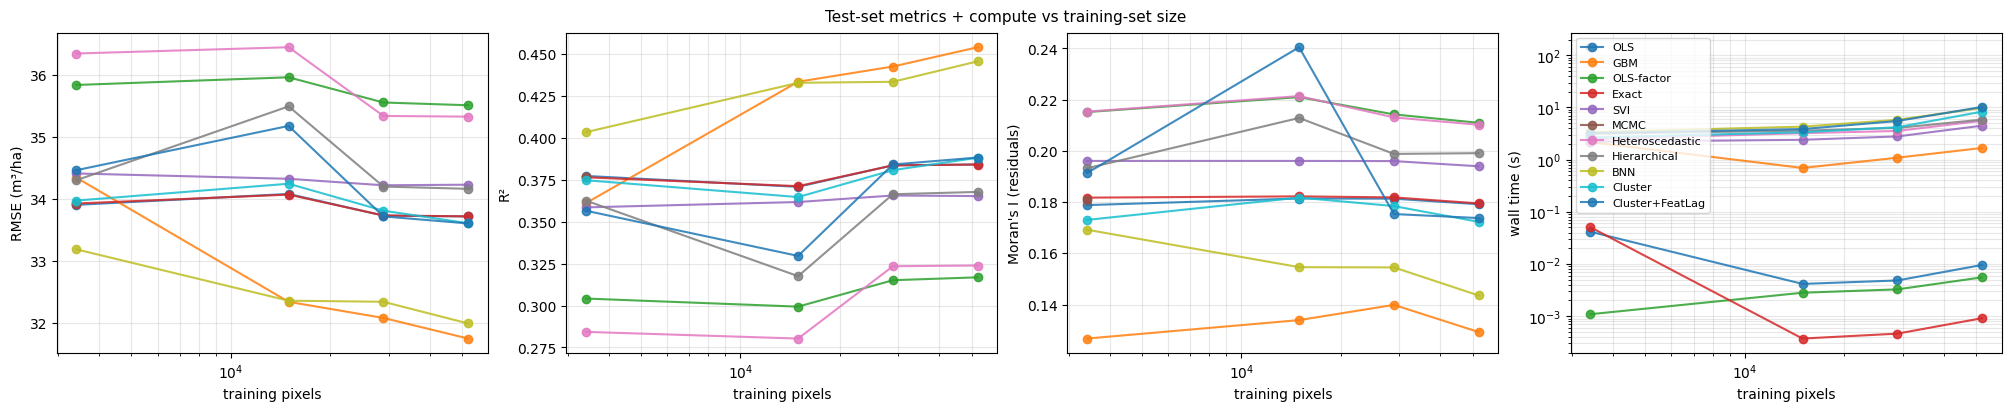

forest plot: skipping models with different feature schema -> ['OLS-factor']


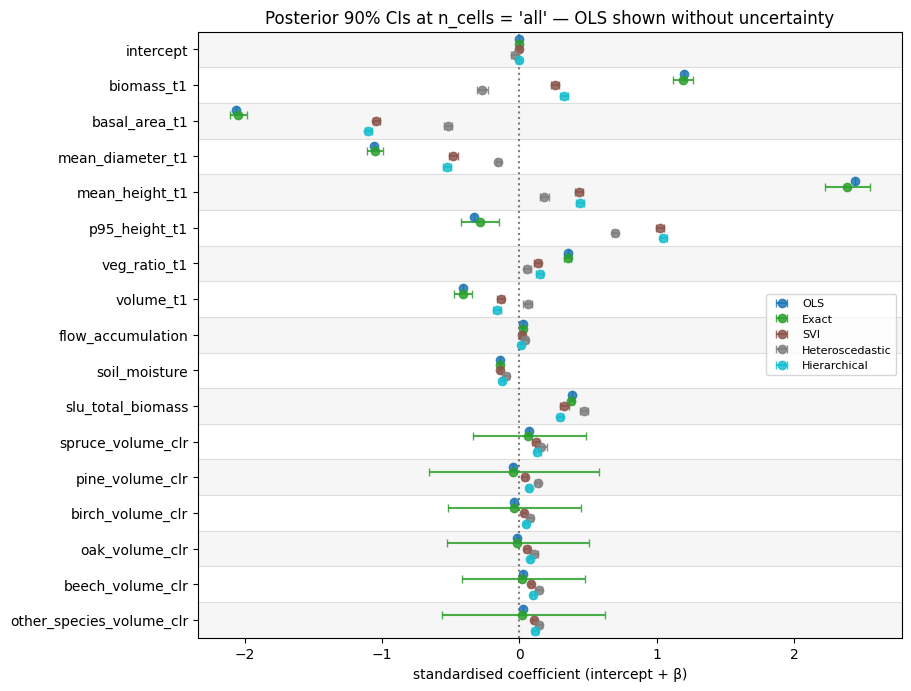

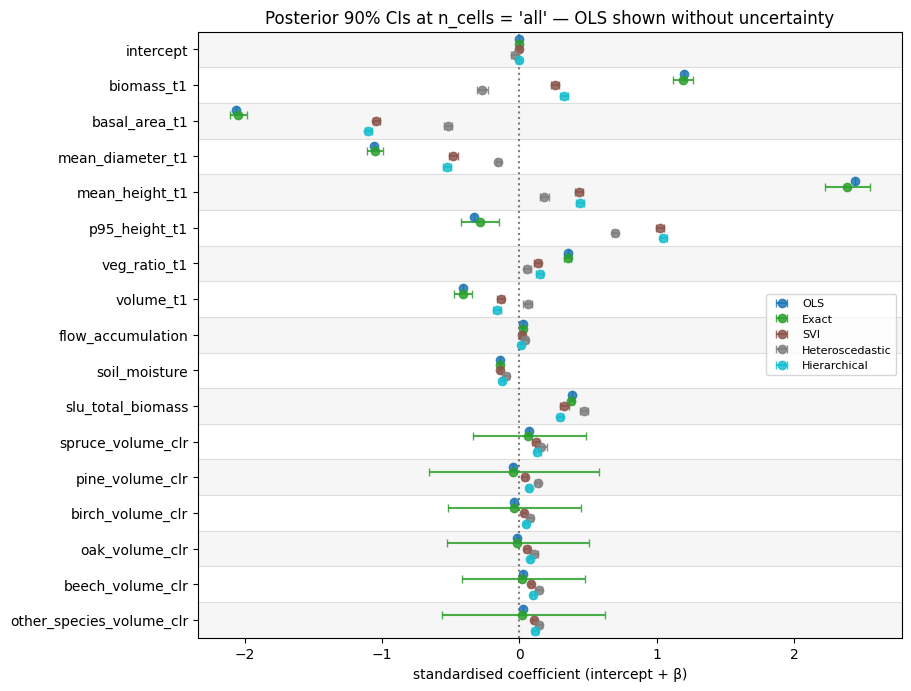

In [ ]:
import matplotlib.pyplot as plt
from notebook_helpers import (scaling_axis_figure, forest_plot,
                               predicted_vs_actual_figure,
                               posterior_predictive_coverage,
                               calibration_figure, spatial_residual_maps,
                               residuals_vs_covariates_figure,
                               posterior_density_overlay,
                               posterior_predictive_density_figure)

# Unified metrics table across all models and scaling steps.
metrics_df = (all_metrics_df()
              .sort_values(["model", "n_train"])
              .reset_index(drop=True))
print(metrics_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# Figure 1: scaling axis (RMSE / R² / Moran's I / wall time vs training pixels).
scaling_axis_figure(MODELS)

# Figure 2: β posterior forest plot at n_cells='all'.
# OLS-factor is skipped (different 12-feature schema) — see §4 for its equivalence test.
forest_plot(MODELS, FEATURE_NAMES, target_step="all")


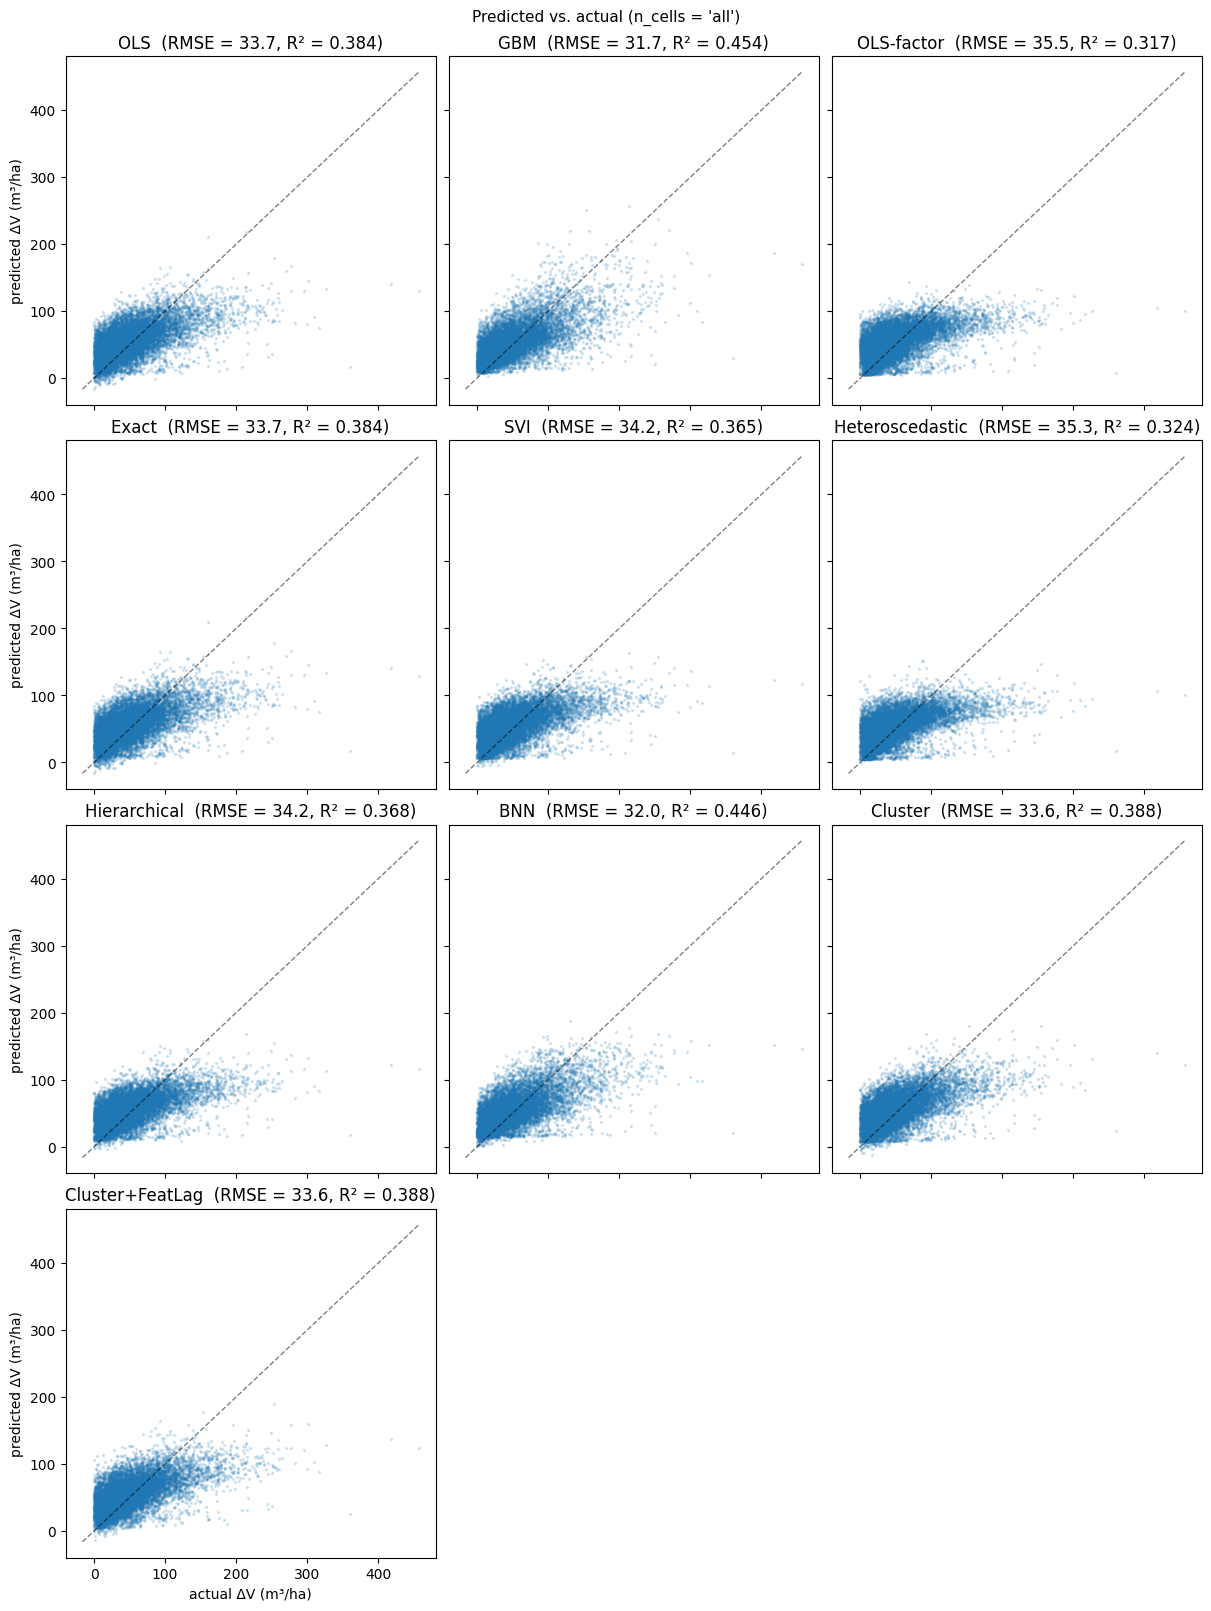

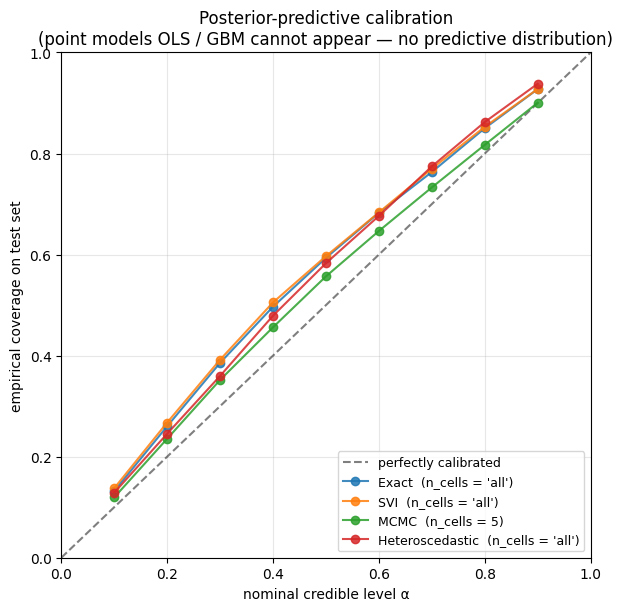

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 7 has 2 dimension(s)

In [43]:
# Figure 3: predicted vs actual at n_cells='all'.
predicted_vs_actual_figure(MODELS, slice_step, target_step="all")

# Figure 4: posterior-predictive calibration — only Bayesian models with sigma_samples appear.
calibration_figure(MODELS, slice_step)

# Figure 5: spatial residual maps at n_cells='all'.
spatial_residual_maps(MODELS, slice_step, target_step="all")


### 9.5 Additional comparison dimensions

The three cells below close the gap to the four-dimensions evaluation framework:

- **Residuals vs top-|β| covariates** (D-gap) — where in *feature space* each model fails.
- **Posterior-density overlay** (F) — visualises agreement between Exact / SVI / NUTS for a few high-magnitude coefficients (course rubric asks for this comparison explicitly).
- **Posterior-predictive density vs observed** (G) — generative sanity check: does the posterior-predictive distribution of $y$ match the observed distribution on the test set?


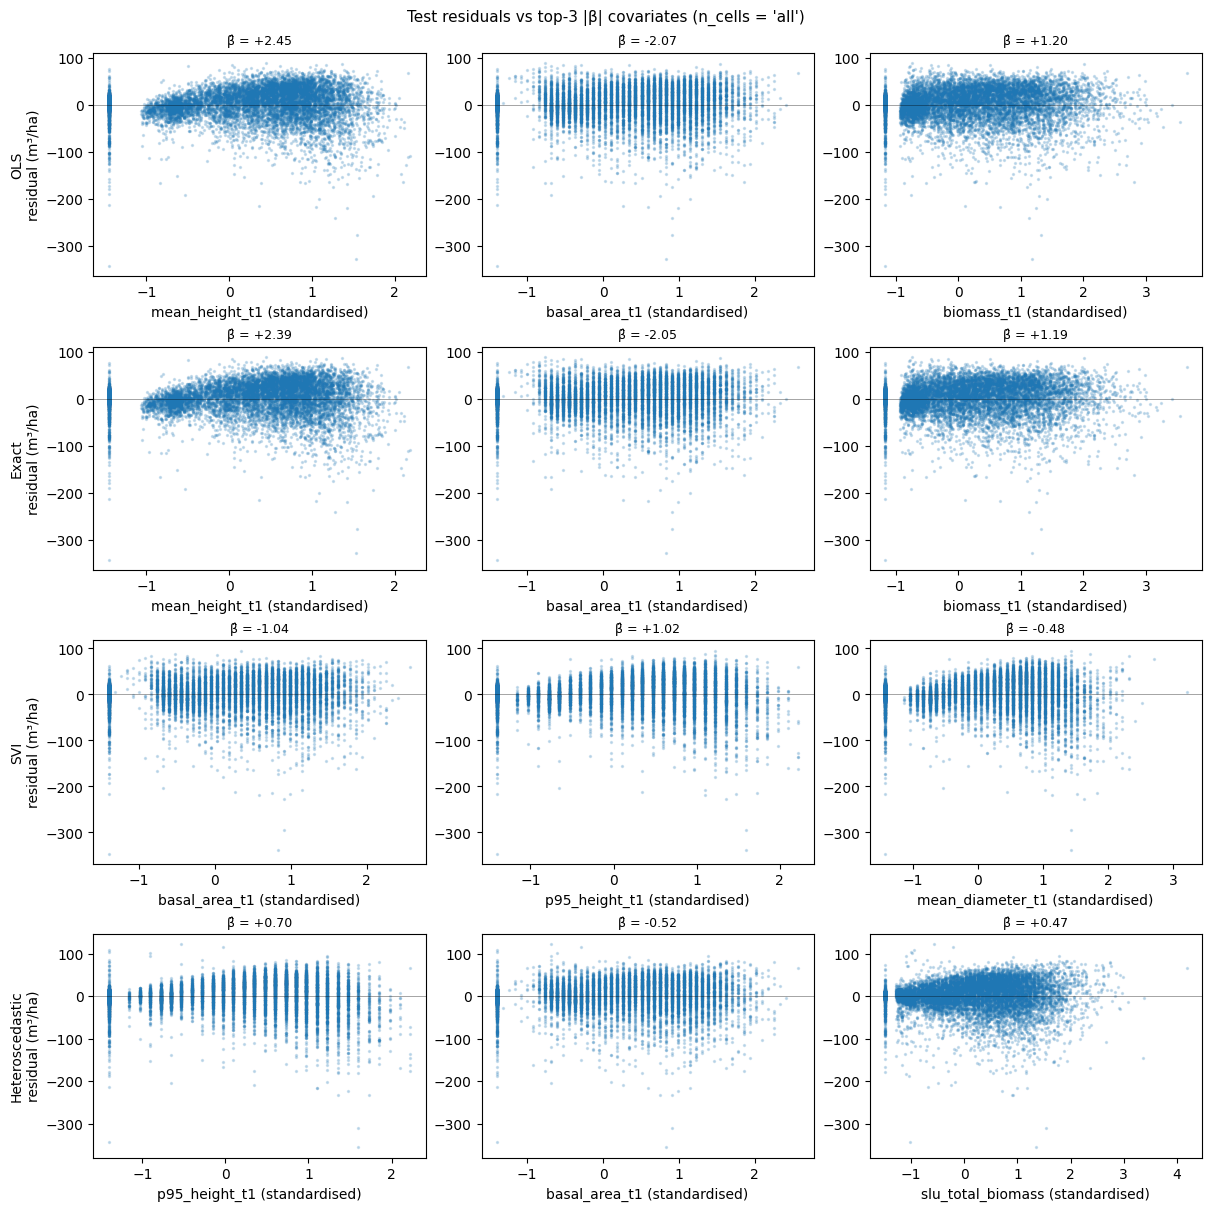

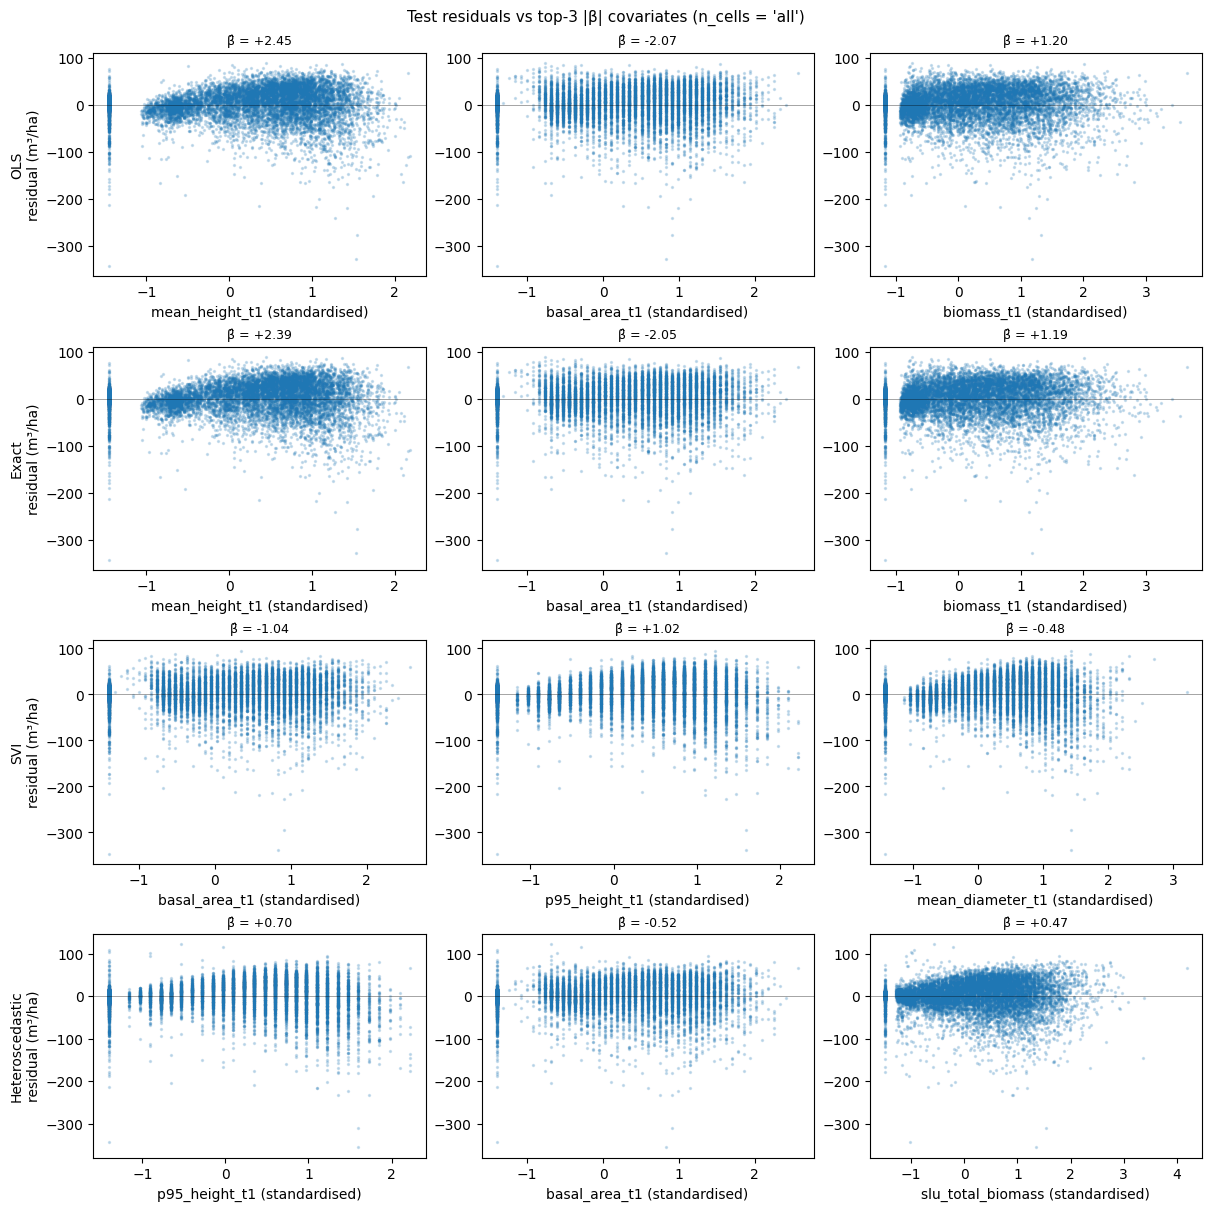

In [ ]:
# D-gap: test residuals vs top-3 |β| covariates per model.
residuals_vs_covariates_figure(MODELS, slice_step, FEATURE_NAMES, target_step="all", top_k=3)


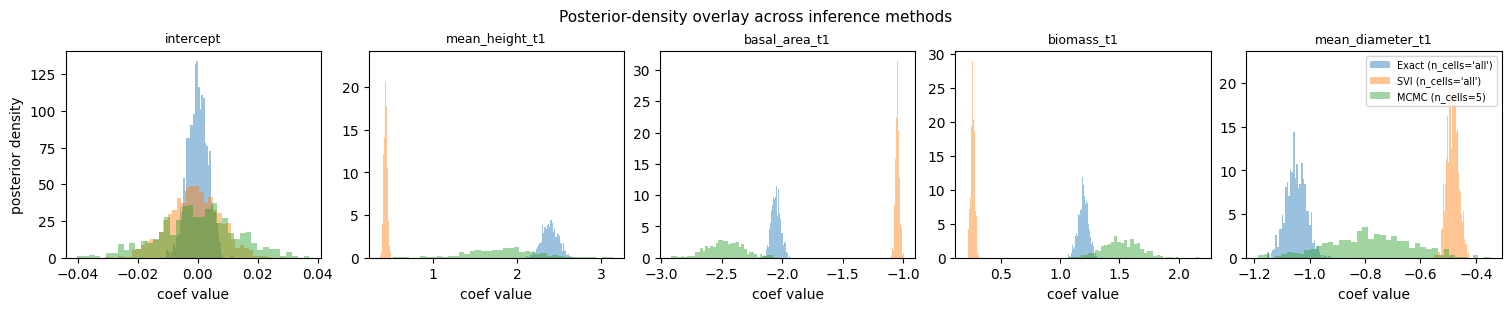

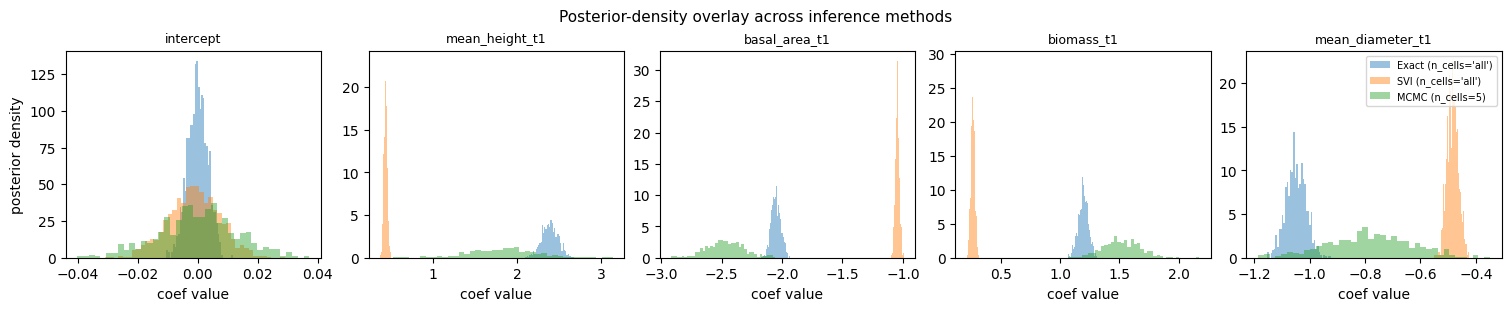

In [ ]:
# F: posterior-density overlay across Exact / SVI / MCMC for the top-4 |β| coefficients.
posterior_density_overlay(MODELS, FEATURE_NAMES, methods=("Exact", "SVI", "MCMC"),
                          target_step="all", top_k=4)


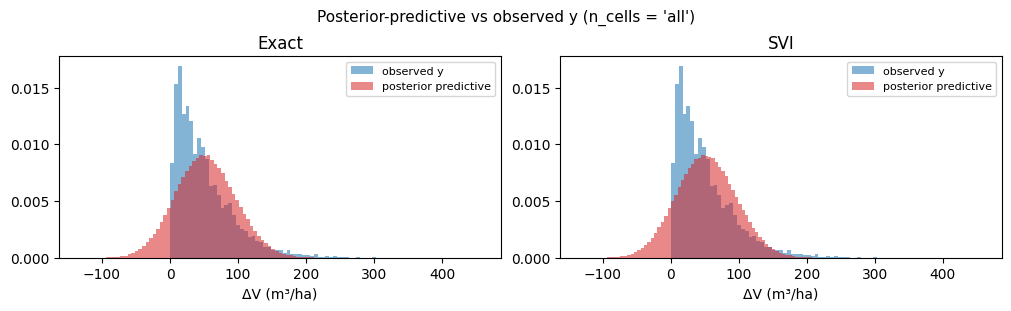

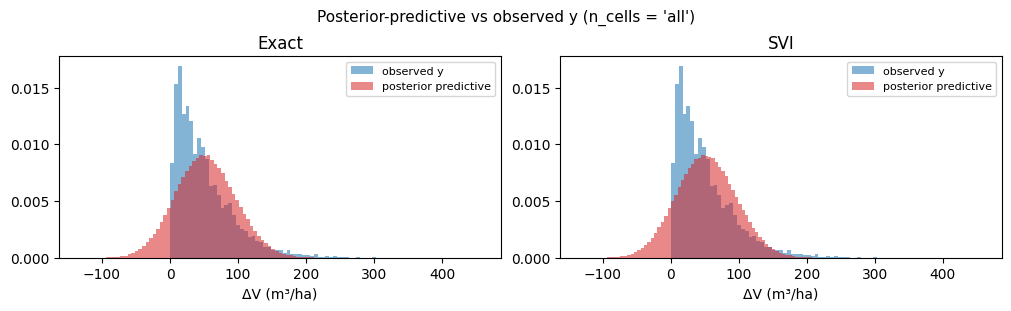

In [ ]:
# G: posterior-predictive density vs observed y on the test set.
posterior_predictive_density_figure(MODELS, slice_step, target_step="all", n_pp=50, seed=SEED)
